# Анализ и визуализация статистических данных с использованием SciPy и Matplotlib

## Введение

Этот Jupyter Notebook предназначен для демонстрации различных методов статистического анализа и визуализации данных с использованием библиотек `NumPy`, `SciPy` и `Matplotlib` в Python. В процессе работы мы рассмотрим как параметрические, так и непараметрические тесты гипотез, методы получения выборок из заданных распределений, а также техники интерполяции и оценки интервалов.

Цель данного проекта — предоставить практическое руководство по применению статистических инструментов для анализа данных, включая проверку нормальности распределения, сравнение средних и дисперсий, а также визуализацию ключевых статистических показателей. Особое внимание будет уделено интепретации результатов и демонстрации Центральной Предельной Теоремы.

Для корректной работы всех примеров убедитесь, что у вас установлены необходимые библиотеки. Их можно установить с помощью следующей команды:

In [1]:
# Установка необходимых библиотек
!pip install numpy scipy matplotlib

## Импорт библиотек

Для выполнения статистических расчетов и построения графиков нам потребуются следующие библиотеки:

* `numpy` для работы с числовыми массивами и математическими операциями.
* `scipy.stats` для статистических функций и тестов.
* `matplotlib.pyplot` для построения графиков.

In [2]:
# Импорт основных библиотек
import numpy as np
import scipy.stats as sst
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Для более тонкой настройки осей графиков
from scipy.interpolate import interp1d
from scipy.integrate import simpson
from collections import Counter


## Краткий обзор функций `scipy.stats`

Библиотека `scipy.stats` предоставляет широкий набор функций для работы с различными вероятностными распределениями и статистическими тестами. Ниже приведены основные методы, доступные для классов распределений (например, `sst.norm` для нормального распределения):

Пусть $X$ — класс, реализующий некоторое распределение. Конкретное распределение с параметрами `params` можно получить как **`X(params)`**.
У него доступны следующие методы:

* `X(params).rvs(size=N)` — генерация выборки размера $N$ (**R**andom **V**ariate**S**). Возвращает `numpy.array`;
* `X(params).cdf(x)` — значение функции распределения в точке $x$ (**C**umulative **D**istribution **F**unction);
* `X(params).ppf(q)` — $q$-квантиль (**P**ercent **P**oint **F**unction), обратная функция к CDF;
* `X(params).mean()` — математическое ожидание;
* `X(params).median()` — медиана ($1/2$-квантиль);
* `X(params).var()` — дисперсия (**Var**iance);
* `X(params).std()` — стандартное отклонение (корень из дисперсии) (**St**andard **D**eviation).
* `X(params).pdf(x)` — для непрерывных распределений значение плотности в точке $x$ (**P**robability **D**ensity **F**unction);
* `X(params).pmf(k)` — для дискретных распределений значение дискретной плотности в точке $k$ (**P**robability **M**ass **F**unction);

Эти методы применимы как к конкретному распределению `X(params)`, так и к самому классу `X`. Во втором случае параметры передаются в сам метод. Например, вызов `X.rvs(size=N, params)` эквивалентен `X(params).rvs(size=N)`. При работе с распределениями и случайными величинами рекомендуется использовать первый способ, поскольку он больше согласуется с математическим синтаксисом теории вероятностей.

Параметры могут быть следующими:
* `loc` — параметр сдвига (обычно среднее);
* `scale` — параметр масштаба (обычно стандартное отклонение);


# I. Параметрические тесты

Параметрические тесты используются, когда данные соответствуют определенным предположениям о распределении (например, нормальному распределению). Мы рассмотрим $t$-критерий Стьюдента для сравнения средних и $F$-критерий для сравнения дисперсий.

## 1. Генерация выборок

Для демонстрации параметрических тестов сгенерируем три выборки из нормального распределения с различными параметрами (среднее, дисперсия) и размерами. Это позволит нам наблюдать различные сценарии при проверке гипотез.

Среднее значение объединенного массива: 0.844


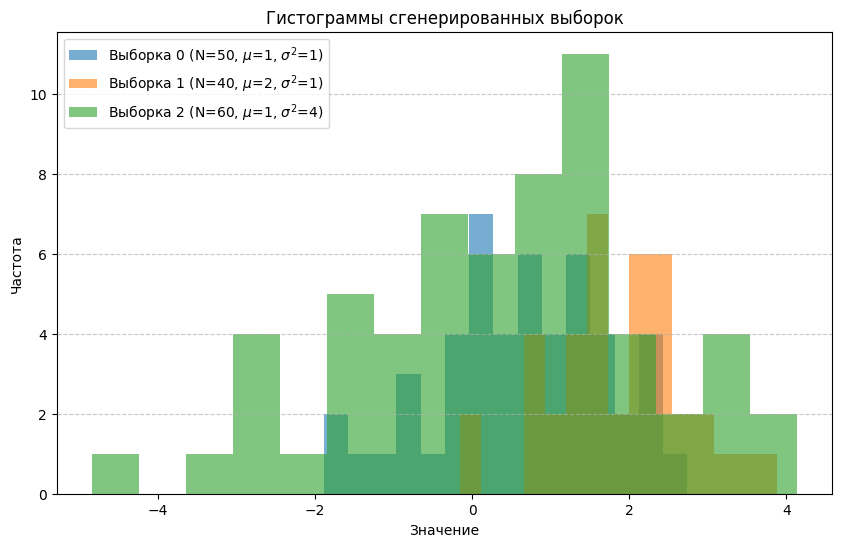

In [3]:
# Параметры для генерации выборок
means = [1, 2, 1]          # Средние значения для каждой выборки
variances = [1, 1, 4]      # Дисперсии для каждой выборки (обратите внимание на variance[2] = 4)
sizes = [50, 40, 60]       # Размеры выборок

# Проверка на соответствие размеров массивов
if not (len(means) == len(variances) == len(sizes)):
    print("Ошибка: Размеры массивов с параметрами должны совпадать!")

# Создание списка выборок (task_arr)
task_arr = []
for i in range(len(sizes)):
    # np.random.normal генерирует данные из нормального распределения.
    # scale - это стандартное отклонение, поэтому берем корень из дисперсии.
    sample = np.random.normal(loc=means[i], scale=np.sqrt(variances[i]), size=sizes[i])
    task_arr.append(sample)

# Объединение всех выборок в один массив (full_arr) для общего анализа
full_arr = np.concatenate(task_arr)

# Вывод среднего значения объединенного массива
print(f"Среднее значение объединенного массива: {np.mean(full_arr):.3f}")

# Визуализация распределения сгенерированных выборок
plt.figure(figsize=(10, 6))
for i, arr in enumerate(task_arr):
    plt.hist(arr, bins=15, alpha=0.6, label=f'Выборка {i} (N={len(arr)}, $\\mu$={means[i]}, $\\sigma^2$={variances[i]})')
plt.title('Гистограммы сгенерированных выборок')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 2. $t$-критерий Стьюдента для независимых выборок (`ttest_ind`)

$t$-критерий Стьюдента используется для проверки гипотезы о равенстве средних двух независимых выборок. Функция `sst.ttest_ind` позволяет выполнить этот тест. Важный параметр `equal_var` определяет, предполагаются ли равные дисперсии генеральных совокупностей:

* Если `equal_var=True`, используется стандартный независимый $t$-тест, который предполагает равные дисперсии (более мощный при выполнении этого условия).
* Если `equal_var=False`, используется $t$-критерий Уэлча, который не предполагает равные дисперсии (более робастный при нарушении условия равенства дисперсий).

Нулевая гипотеза ($H_0$): Средние значения двух выборок равны.
Альтернативная гипотеза ($H_1$): Средние значения двух выборок не равны.

Мы отвергаем $H_0$, если $p$-значение меньше уровня значимости $\alpha$ (обычно 0.05).

In [4]:
# Уровень значимости
alpha = 0.05

print("### Сравнение Выборки 0 и Выборки 1 ###")
# Сравнение выборок task_arr[0] и task_arr[1] с предположением равных дисперсий
t_stat_eq, p_value_eq = sst.ttest_ind(task_arr[0], task_arr[1], equal_var=True)
print(f"T-тест (равные дисперсии): t-статистика = {t_stat_eq:.3f}, p-значение = {p_value_eq:.3f}")
if p_value_eq < alpha:
   print("  -> Отвергаем H0: существует статистически значимое различие между средними (p < 0.05).")
else:
   print("  -> Не отвергаем H0: нет статистически значимого различия между средними (p >= 0.05).")

# Сравнение выборок task_arr[0] и task_arr[1] без предположения равных дисперсий (критерий Уэлча)
t_stat_uneq, p_value_uneq = sst.ttest_ind(task_arr[0], task_arr[1], equal_var=False)
print(f"T-тест (неравные дисперсии): t-статистика = {t_stat_uneq:.3f}, p-значение = {p_value_uneq:.3f}")
if p_value_uneq < alpha:
   print("  -> Отвергаем H0: существует статистически значимое различие между средними (p < 0.05).")
else:
   print("  -> Не отвергаем H0: нет статистически значимого различия между средними (p >= 0.05).")

print("\n### Сравнение Выборки 0 и Выборки 2 ###")
# Сравнение выборок task_arr[0] и task_arr[2]
t_stat_02_eq, p_value_02_eq = sst.ttest_ind(task_arr[0], task_arr[2], equal_var=True)
print(f"T-тест (равные дисперсии): t-статистика = {t_stat_02_eq:.3f}, p-значение = {p_value_02_eq:.3f}")
if p_value_02_eq < alpha:
   print("  -> Отвергаем H0: существует статистически значимое различие между средними (p < 0.05).")
else:
   print("  -> Не отвергаем H0: нет статистически значимого различия между средними (p >= 0.05).")

t_stat_02_uneq, p_value_02_uneq = sst.ttest_ind(task_arr[0], task_arr[2], equal_var=False)
print(f"T-тест (неравные дисперсии): t-статистика = {t_stat_02_uneq:.3f}, p-значение = {p_value_02_uneq:.3f}")
if p_value_02_uneq < alpha:
   print("  -> Отвергаем H0: существует статистически значимое различие между средними (p < 0.05).")
else:
   print("  -> Не отвергаем H0: нет статистически значимого различия между средними (p >= 0.05).")

print("\n### Сравнение Выборки 1 и Выборки 2 ###")
# Сравнение выборок task_arr[1] и task_arr[2]
t_stat_12_eq, p_value_12_eq = sst.ttest_ind(task_arr[1], task_arr[2], equal_var=True)
print(f"T-тест (равные дисперсии): t-статистика = {t_stat_12_eq:.3f}, p-значение = {p_value_12_eq:.3f}")
if p_value_12_eq < alpha:
   print("  -> Отвергаем H0: существует статистически значимое различие между средними (p < 0.05).")
else:
   print("  -> Не отвергаем H0: нет статистически значимого различия между средними (p >= 0.05).")

t_stat_12_uneq, p_value_12_uneq = sst.ttest_ind(task_arr[1], task_arr[2], equal_var=False)
print(f"T-тест (неравные дисперсии): t-статистика = {t_stat_12_uneq:.3f}, p-значение = {p_value_12_uneq:.3f}")
if p_value_12_uneq < alpha:
   print("  -> Отвергаем H0: существует статистически значимое различие между средними (p < 0.05).")
else:
   print("  -> Не отвергаем H0: нет статистически значимого различия между средними (p >= 0.05).")


### Сравнение Выборки 0 и Выборки 1 ###
T-тест (равные дисперсии): t-статистика = -5.803, p-значение = 0.000
  -> Отвергаем H0: существует статистически значимое различие между средними (p < 0.05).
T-тест (неравные дисперсии): t-статистика = -5.947, p-значение = 0.000
  -> Отвергаем H0: существует статистически значимое различие между средними (p < 0.05).

### Сравнение Выборки 0 и Выборки 2 ###
T-тест (равные дисперсии): t-статистика = 0.835, p-значение = 0.406
  -> Не отвергаем H0: нет статистически значимого различия между средними (p >= 0.05).
T-тест (неравные дисперсии): t-статистика = 0.873, p-значение = 0.385
  -> Не отвергаем H0: нет статистически значимого различия между средними (p >= 0.05).

### Сравнение Выборки 1 и Выборки 2 ###
T-тест (равные дисперсии): t-статистика = 4.690, p-значение = 0.000
  -> Отвергаем H0: существует статистически значимое различие между средними (p < 0.05).
T-тест (неравные дисперсии): t-статистика = 5.340, p-значение = 0.000
  -> Отвергаем H0: су

## 3. $F$-критерий для проверки равенства дисперсий

$F$-критерий (или критерий Фишера) используется для проверки гипотезы о равенстве дисперсий двух генеральных совокупностей. Нулевая гипотеза ($H_0$) заключается в том, что дисперсии равны.

$$ F = \frac{s_1^2}{s_2^2} $$

где $s_1^2$ и $s_2^2$ — выборочные дисперсии. Значение $p$-value вычисляется с использованием кумулятивной функции распределения Фишера (`sst.f.cdf`).

### Проверка равенства дисперсий с помощью F-теста ###
F-тест (Выборка 0 vs Выборка 1):
  Дисперсия Выборка 0: 1.200, Дисперсия Выборка 1: 0.769
  F-статистика = 1.560, p-значение = 0.153
  -> Не отвергаем H0: нет статистически значимого различия в дисперсиях (p >= 0.05).
F-тест (Выборка 0 vs Выборка 2):
  Дисперсия Выборка 0: 1.200, Дисперсия Выборка 2: 3.499
  F-статистика = 2.915, p-значение = 0.000
  -> Отвергаем H0: существует статистически значимое различие в дисперсиях (p < 0.05).
F-тест (Выборка 1 vs Выборка 2):
  Дисперсия Выборка 1: 0.769, Дисперсия Выборка 2: 3.499
  F-статистика = 4.548, p-значение = 0.000
  -> Отвергаем H0: существует статистически значимое различие в дисперсиях (p < 0.05).


/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_32803/766060886.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(task_arr, labels=[f'Выборка {i}' for i in range(len(task_arr))], patch_artist=True)


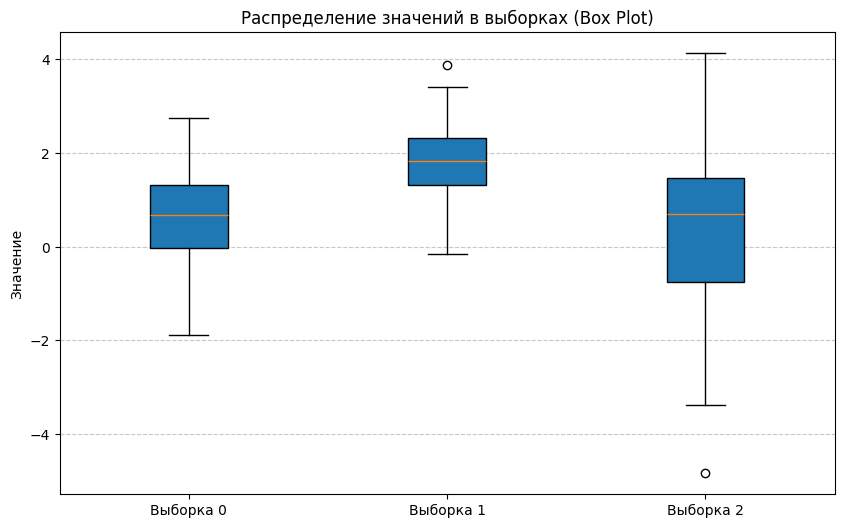

In [5]:
# Функция для выполнения F-теста и вывода результатов
def f_test_and_print(sample1, sample2, name1, name2, alpha=0.05):
    # Вычисляем степени свободы
    df1 = len(sample1) - 1
    df2 = len(sample2) - 1

    # Вычисляем F-статистику. Для двустороннего теста, мы можем взять большее отношение дисперсий.
    # Однако, scipy.stats.f.cdf принимает отношение в определенном порядке.
    # Для симметричности обычно используется отношение большей дисперсии к меньшей.
    var1 = np.var(sample1, ddof=1) # ddof=1 для несмещенной оценки выборочной дисперсии
    var2 = np.var(sample2, ddof=1)

    if var1 >= var2:
        f_stat = var1 / var2
        p_value = 2 * min(sst.f.cdf(f_stat, df1, df2), 1 - sst.f.cdf(f_stat, df1, df2))
        # Примечание: Для двустороннего F-теста часто берут 2 * min(p, 1-p).
        # Здесь мы используем односторонний CDF, так как sst.f.cdf(f_stat, df1, df2) уже дает вероятность хвоста.
        # Для двустороннего p-value: p_value = 2 * sst.f.cdf(1/f_stat, df2, df1) if f_stat > 1 else 2 * sst.f.sf(f_stat, df1, df2)
        # Более простой подход для F-теста на равенство дисперсий:
        # stats.fligner(sample1, sample2) или stats.levene(sample1, sample2)
        # Используем sst.f.sf (survival function) для p-value в двустороннем тесте, умножая на 2
        p_value = 2 * sst.f.sf(f_stat, df1, df2)
    else:
        f_stat = var2 / var1
        p_value = 2 * sst.f.sf(f_stat, df2, df1)
    
    print(f"F-тест ({name1} vs {name2}):")
    print(f"  Дисперсия {name1}: {var1:.3f}, Дисперсия {name2}: {var2:.3f}")
    print(f"  F-статистика = {f_stat:.3f}, p-значение = {p_value:.3f}")

    if p_value < alpha:
        print("  -> Отвергаем H0: существует статистически значимое различие в дисперсиях (p < 0.05).")
    else:
        print("  -> Не отвергаем H0: нет статистически значимого различия в дисперсиях (p >= 0.05).")

# Уровень значимости
alpha = 0.05

# Сравнение всех пар выборок
print("### Проверка равенства дисперсий с помощью F-теста ###")
f_test_and_print(task_arr[0], task_arr[1], "Выборка 0", "Выборка 1", alpha)
f_test_and_print(task_arr[0], task_arr[2], "Выборка 0", "Выборка 2", alpha)
f_test_and_print(task_arr[1], task_arr[2], "Выборка 1", "Выборка 2", alpha)

# Дополнительная визуализация дисперсий с помощью boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(task_arr, labels=[f'Выборка {i}' for i in range(len(task_arr))], patch_artist=True)
plt.title('Распределение значений в выборках (Box Plot)')
plt.ylabel('Значение')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 4. Критерий Д'Агостино-Пирсона для проверки нормальности (`normaltest`)

Критерий Д'Агостино-Пирсона (`sst.normaltest`) — это статистический тест, используемый для проверки нормальности распределения данных. Он основан на отклонениях асимметрии (skewness) и эксцесса (kurtosis) выборки от значений, ожидаемых для нормального распределения.

Нулевая гипотеза ($H_0$): Данные распределены нормально.
Альтернативная гипотеза ($H_1$): Данные не распределены нормально.

Если $p$-значение меньше $\alpha$, мы отвергаем $H_0$.

### Результаты критерия Д'Агостино-Пирсона для объединенной выборки ###
Статистика = 14.714, p-значение = 0.001
  -> Отвергаем H0: генеральная совокупность не распределена нормально (p < 0.05).


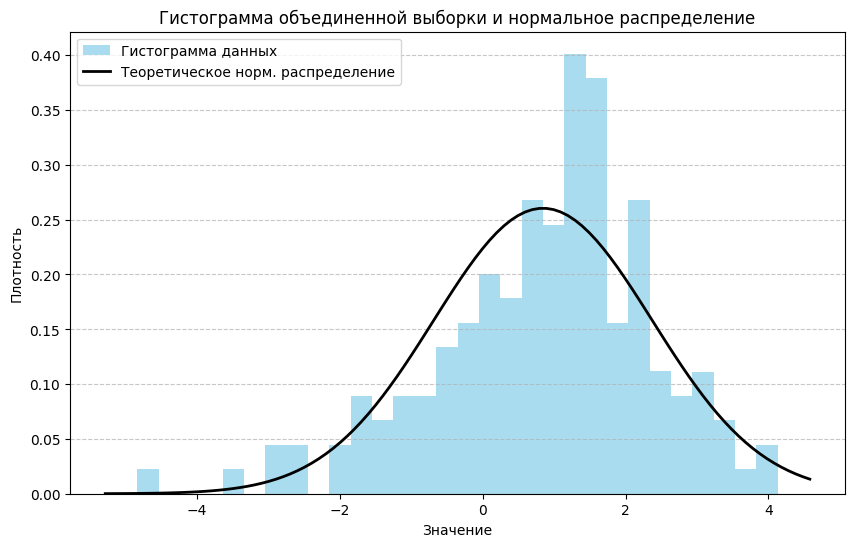

In [6]:
# Применяем критерий Д'Агостино-Пирсона к объединенной выборке (full_arr)
statistic, p_value = sst.normaltest(full_arr)

print("### Результаты критерия Д'Агостино-Пирсона для объединенной выборки ###")
print(f"Статистика = {statistic:.3f}, p-значение = {p_value:.3f}")

# Интерпретация результатов
if p_value < alpha:
   print("  -> Отвергаем H0: генеральная совокупность не распределена нормально (p < 0.05).")
else:
   print("  -> Не отвергаем H0: генеральная совокупность распределена нормально (p >= 0.05).")

# Визуализация объединенного распределения с наложенной нормальной кривой
plt.figure(figsize=(10, 6))
plt.hist(full_arr, bins=30, density=True, alpha=0.7, color='skyblue', label='Гистограмма данных')

# Построение плотности нормального распределения с параметрами данных
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = sst.norm.pdf(x, np.mean(full_arr), np.std(full_arr))
plt.plot(x, p, 'k', linewidth=2, label='Теоретическое норм. распределение')

plt.title('Гистограмма объединенной выборки и нормальное распределение')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# II. Методы получения выборки: Аппроксимация методом отбрасывания

Когда аналитическое распределение неизвестно или слишком сложно для прямого сэмплирования, можно использовать метод отбрасывания (Acceptance-Rejection Sampling). Этот метод позволяет генерировать выборки из произвольного распределения $p(x)$ при наличии вспомогательного распределения $q(x)$ и константы $M$ такой, что $M \cdot q(x) \ge p(x)$ для всех $x$.

Процесс выглядит следующим образом:
1.  Генерируем случайную точку $x$ из распределения $q(x)$.
2.  Генерируем случайную точку $y$ из равномерного распределения от $0$ до $M \cdot q(x)$.
3.  Если $y \leq p(x)$, то точка $(x, y)$ принимается; в противном случае она отбрасывается.

Рассмотрим пример с ненормализованным распределением $p(x) = \sin(x^2) + 1$ на интервале $[0, 4]$. В качестве вспомогательного распределения $q(x)$ используем равномерное распределение на том же интервале, а $M$ будет максимальным значением $p(x)$.

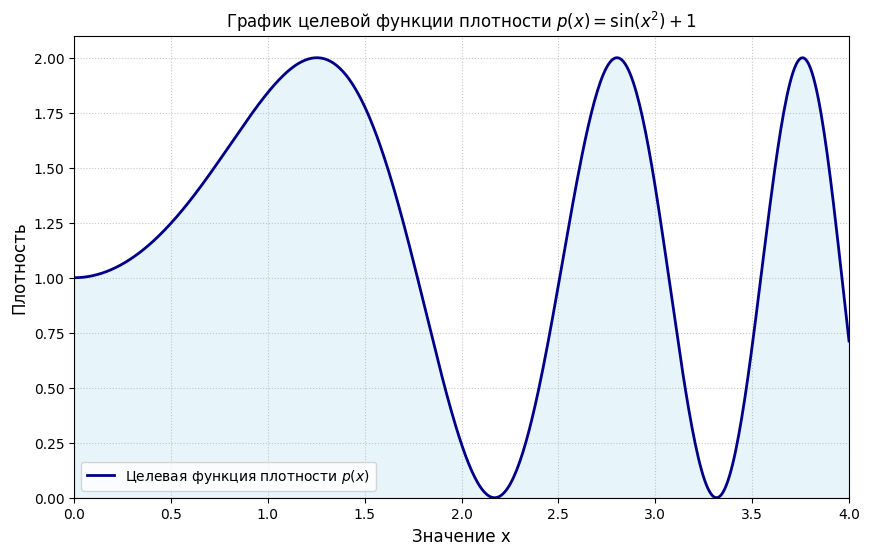

In [7]:
# Определение функции плотности вероятности (PDF) для сэмплирования
def my_pdf(x):  
    return np.sin(x**2) + 1

# Диапазон значений x для построения графика
xs = np.linspace(0, 4, 500)  # Увеличиваем количество точек для более гладкого графика
ps = my_pdf(xs)

plt.figure(figsize=(10, 6))
plt.plot(xs, ps, color='darkblue', linewidth=2, label='Целевая функция плотности $p(x)$')
plt.fill_between(xs, 0, ps, alpha=0.2, color='skyblue')

plt.title(r'График целевой функции плотности $p(x) = \sin(x^2) + 1$')
plt.xlabel('Значение x', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.grid(ls=':', alpha=0.7)
plt.xlim(0, 4)
plt.ylim(0, 2.1)  # Немного увеличим ylim для наглядности
plt.legend()
plt.show()


## 1. Генерация случайных точек для метода отбрасывания

Мы генерируем случайные $x$ из равномерного распределения на $[0, 4]$ и случайные $y$ из равномерного распределения на $[0, M]$, где $M$ — максимальное значение нашей функции $p(x)$ (в данном случае $M=2$).

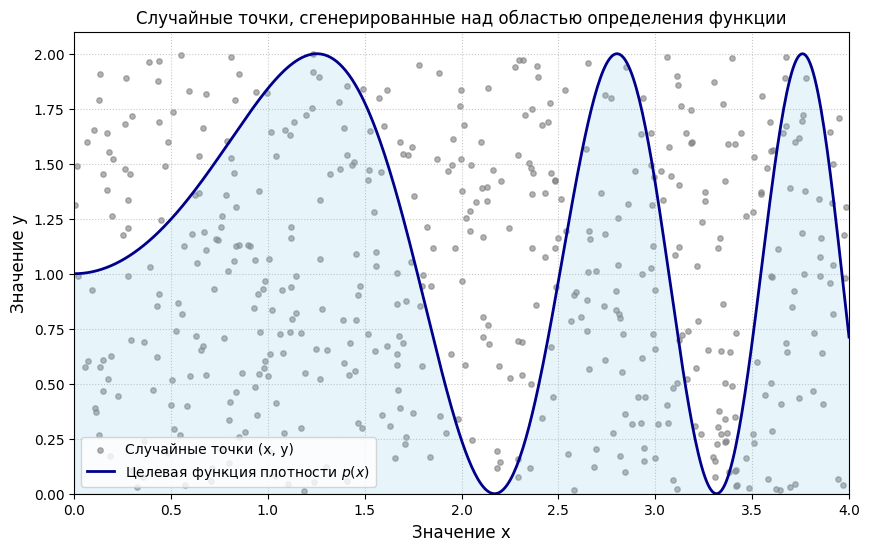

In [8]:
n_points = 500 # Количество случайных точек для визуализации

# Генерация случайных x из равномерного распределения [0, 4]
random_x = sst.uniform.rvs(loc=0, scale=4, size=n_points)
# Генерация случайных y из равномерного распределения [0, M], где M = 2 (максимум sin(x^2) + 1)
random_y = sst.uniform.rvs(loc=0, scale=2, size=n_points)

plt.figure(figsize=(10, 6))
plt.scatter(random_x, random_y, s=15, alpha=0.6, color='grey', label='Случайные точки (x, y)')
plt.plot(xs, ps, color='darkblue', linewidth=2, label='Целевая функция плотности $p(x)$')
plt.fill_between(xs, 0, ps, color="skyblue", alpha=0.2)

plt.title('Случайные точки, сгенерированные над областью определения функции')
plt.xlabel('Значение x', fontsize=12)
plt.ylabel('Значение y', fontsize=12)
plt.grid(ls=':', alpha=0.7)
plt.xlim(0, 4)
plt.ylim(0, 2.1)
plt.legend()
plt.show()


## 2. Отбор точек по условию `y <= p(x)`

На этом шаге мы фильтруем сгенерированные точки. Точки, для которых `random_y <= my_pdf(random_x)`, принимаются, а остальные отбрасываются. Принятые точки формируют выборку, которая аппроксимирует целевое распределение.

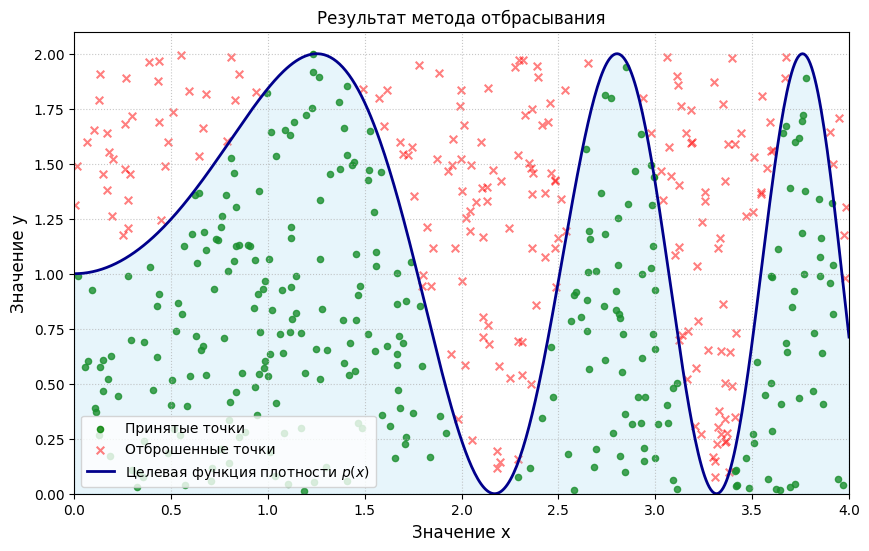

In [9]:
# Фильтрация точек: True, если y <= p(x), False в противном случае
passed = random_y <= my_pdf(random_x)

plt.figure(figsize=(10, 6))
# Отображение принятых точек (синим)
plt.scatter(random_x[passed], random_y[passed], s=20, alpha=0.8, color='green', label='Принятые точки')
# Отображение отброшенных точек (красными крестиками)
plt.scatter(random_x[~passed], random_y[~passed], marker="x", s=30, alpha=0.5, color='red', label='Отброшенные точки')

plt.plot(xs, ps, color='darkblue', linewidth=2, label='Целевая функция плотности $p(x)$')
plt.fill_between(xs, 0, ps, color="skyblue", alpha=0.2)

plt.title('Результат метода отбрасывания')
plt.xlabel('Значение x', fontsize=12)
plt.ylabel('Значение y', fontsize=12)
plt.grid(ls=':', alpha=0.7)
plt.xlim(0, 4)
plt.ylim(0, 2.1)
plt.legend()
plt.show()


## 3. Сэмплирование большого количества точек и сравнение с истинным PDF

Для подтверждения эффективности метода отбрасывания, сгенерируем значительно больше точек (`n2 = 100000`) и сравним гистограмму полученной выборки с нормированной функцией плотности $p(x)$. Нормировка функции $p(x)$ выполняется путем деления на ее интеграл (площадь под кривой), вычисленный методом Симпсона.

Количество точек в итоговой выборке: 59466


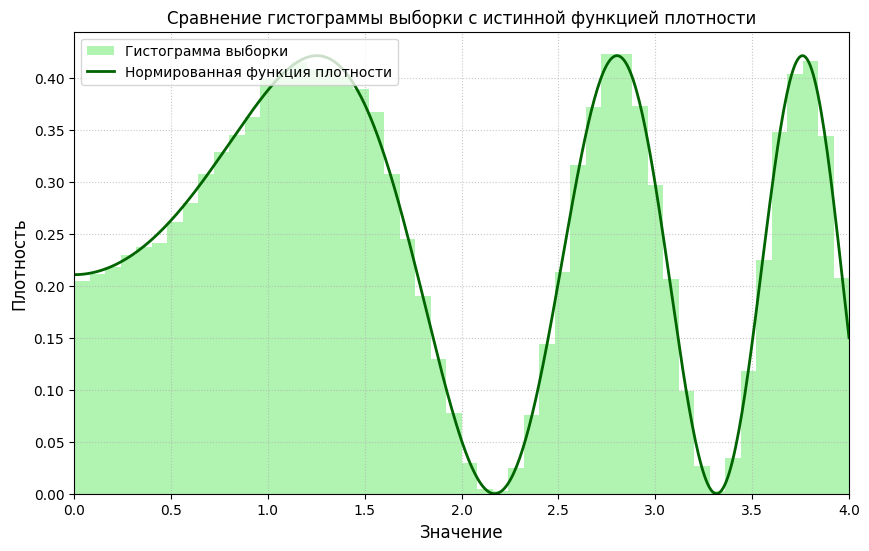

In [10]:
n2 = 100000  # Большое количество точек для точного сэмплирования

# Генерация случайных x и y для метода отбрасывания
x_test = sst.uniform.rvs(scale=4, size=n2) # x из [0, 4]
y_test_check = sst.uniform.rvs(scale=2, size=n2) # y из [0, 2]

# Отбор точек, где y_test_check <= my_pdf(x_test)
x_final = x_test[y_test_check <= my_pdf(x_test)]

print(f"Количество точек в итоговой выборке: {len(x_final)}")

# Вычисление нормализующего множителя (интеграл от my_pdf) с помощью метода Симпсона
normalisation_factor = simpson(ps, x=xs)

plt.figure(figsize=(10, 6))
plt.hist(x_final, bins=50, density=True, histtype="stepfilled", 
         alpha=0.7, color='lightgreen', label="Гистограмма выборки")

plt.plot(xs, ps / normalisation_factor, color='darkgreen', 
         linewidth=2, label="Нормированная функция плотности")

plt.title('Сравнение гистограммы выборки с истинной функцией плотности')
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.grid(ls=':', alpha=0.7)
plt.legend(loc='upper left')
plt.xlim(0, 4)
plt.show()


# III. Выборка методом обратного преобразования (Inverse Transform Sampling)

Метод обратного преобразования — это эффективный способ генерации случайных чисел из произвольного распределения, если известна его обратная кумулятивная функция распределения (ICDF, Inverse Cumulative Distribution Function) или функция квантилей (PPF).

Основная идея:
1.  Мы знаем, что для любого PDF, значение CDF изменяется от 0 до 1.
2.  Если можно равномерно отобрать значения $U$ из интервала $[0, 1]$ (из равномерного распределения).
3.  Тогда $X = F^{-1}(U)$ будет выборкой из желаемого распределения, где $F^{-1}$ — это обратная CDF (или PPF).

Этот метод особенно удобен, когда $F^{-1}(U)$ имеет простую аналитическую форму. Для сложных функций (как `my_pdf` из предыдущего раздела) аналитическое выражение для $F^{-1}(U)$ может быть невозможно найти.

Рассмотрим пример с PDF: $p(x) = 3x^2$ на интервале $[0, 1]$.

1.  **Кумулятивная функция распределения (CDF):**
    $$ F(x) = \int_0^x p(t) dt = \int_0^x 3t^2 dt = [t^3]_0^x = x^3 $$
2.  **Обратная кумулятивная функция распределения (ICDF) / Функция квантилей (PPF):**
    Пусть $U = F(x) = x^3$. Тогда $x = U^{1/3}$.
    Таким образом, $ICDF(U) = U^{1/3}$.

Мы будем генерировать случайные числа $U$ из равномерного распределения и применять к ним $ICDF(U)$, чтобы получить выборку из $p(x) = 3x^2$.

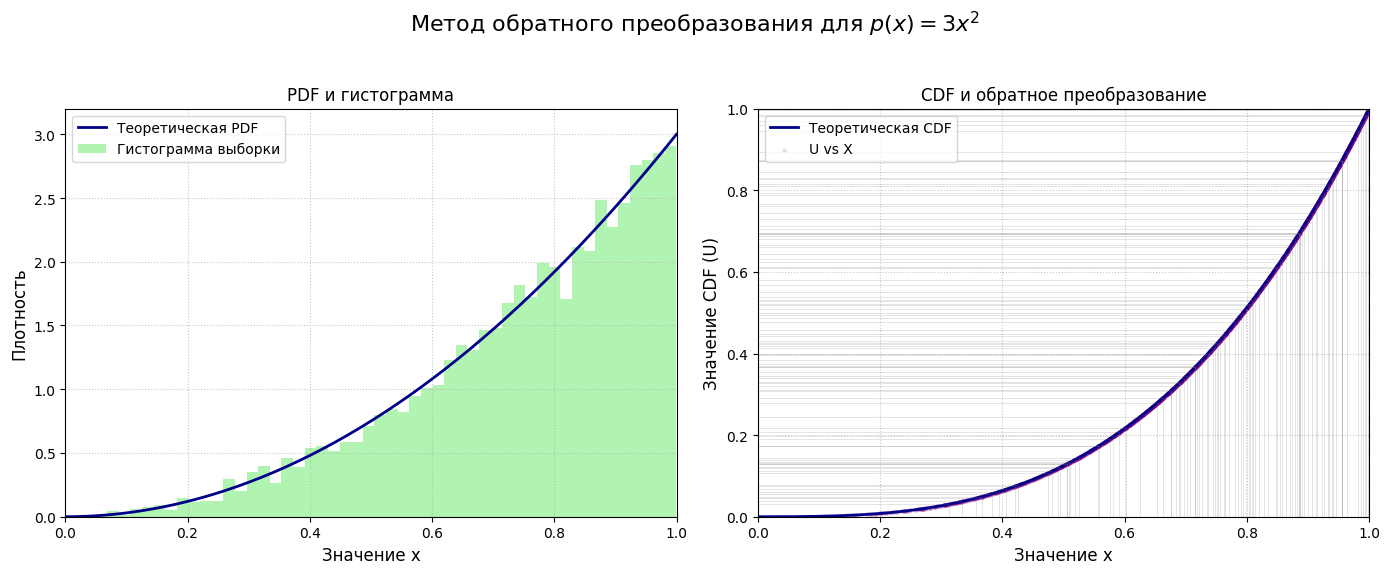

In [11]:
# Определение функций PDF, CDF и ICDF для примера p(x) = 3x^2
def pdf_cubic(x):  
    return 3 * x**2

def cdf_cubic(x):  
    return x**3

def icdf_cubic(u):  
    return u**(1/3)

# Диапазон значений x
xs_cubic = np.linspace(0, 1, 200) # Увеличим количество точек для гладкости

# Значения PDF и CDF для построения графиков
pdfs_cubic = pdf_cubic(xs_cubic)
cdfs_cubic = cdf_cubic(xs_cubic)

n_samples = 5000 # Количество выборок

# Генерация равномерно распределенных случайных чисел (U)
u_samps = sst.uniform.rvs(size=n_samples)

# Применение обратной CDF для получения выборки из желаемого распределения
x_samps = icdf_cubic(u_samps)

# Построение двух диаграмм рядом: PDF и CDF
fig, axes = plt.subplots(ncols=2, figsize=(14, 6))
fig.suptitle('Метод обратного преобразования для $p(x) = 3x^2$', fontsize=16)

# График PDF и гистограмма выборки
axes[0].plot(xs_cubic, pdfs_cubic, color='darkblue', linewidth=2, label='Теоретическая PDF')
axes[0].hist(x_samps, bins=50, density=True, histtype="stepfilled", 
             alpha=0.7, color='lightgreen', label="Гистограмма выборки")
axes[0].set_title('PDF и гистограмма')
axes[0].set_xlabel('Значение x', fontsize=12)
axes[0].set_ylabel('Плотность', fontsize=12)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 3.2)
axes[0].legend(loc='upper left')
axes[0].grid(ls=':', alpha=0.7)

# График CDF и визуализация преобразования
axes[1].plot(xs_cubic, cdfs_cubic, color='darkblue', linewidth=2, label='Теоретическая CDF')

# Визуализация преобразования: равномерные U по оси Y, соответствующие X по оси X
for i in range(min(100, n_samples)):
    axes[1].hlines(u_samps[i], 0, x_samps[i], linewidth=0.5, alpha=0.3, color='gray')
    axes[1].vlines(x_samps[i], 0, u_samps[i], linewidth=0.5, alpha=0.3, color='gray')
axes[1].scatter(x_samps, u_samps, s=5, alpha=0.1, color='purple', label='U vs X')

axes[1].set_title('CDF и обратное преобразование')
axes[1].set_xlabel('Значение x', fontsize=12)
axes[1].set_ylabel('Значение CDF (U)', fontsize=12)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper left')
axes[1].grid(ls=':', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Регулировка layout для избежания наложения заголовка
plt.show()


## 1. Применение метода обратного преобразования к `my_pdf` (численный подход)

Для функций, у которых нет простой аналитической обратной CDF, можно использовать численные методы. Мы вычисляем CDF путем кумулятивного суммирования значений PDF, нормализуем ее, а затем используем интерполяцию (`interp1d`) для нахождения обратной функции. Это позволяет нам применять метод обратного преобразования даже для сложных распределений.

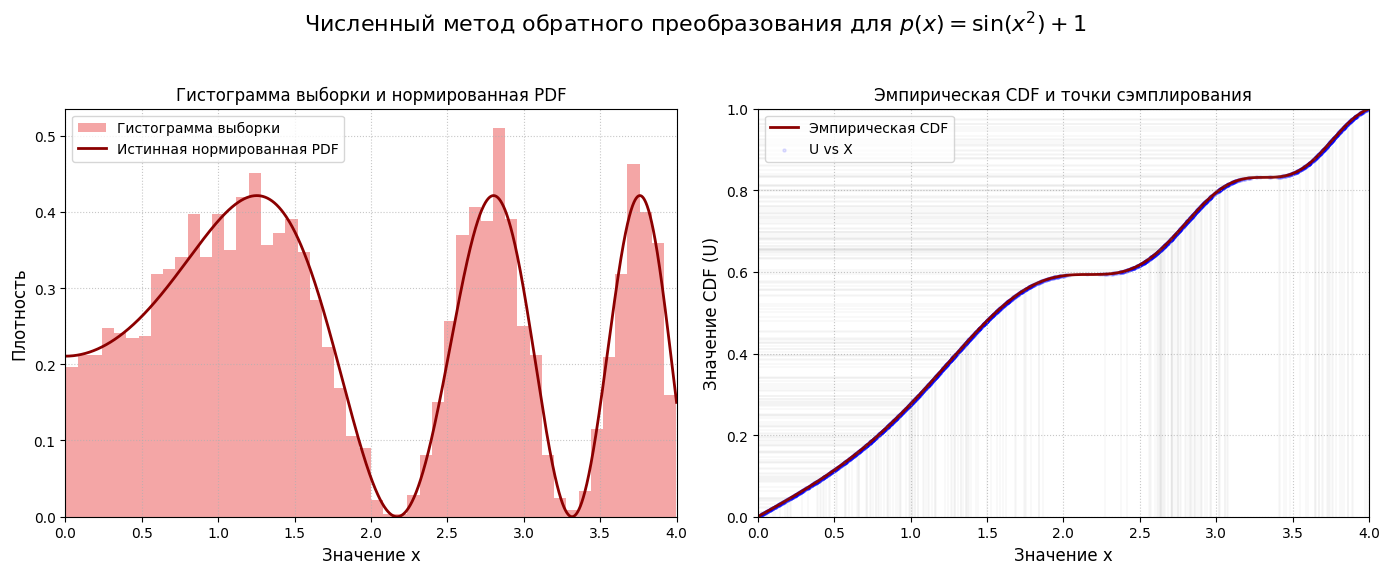

In [12]:
# Определение функции плотности (my_pdf) из предыдущего раздела
def my_pdf(x):  
    return np.sin(x**2) + 1

# Создание массива значений x с высокой плотностью для точного вычисления CDF
xs_fine = np.linspace(0, 4, 4000)  # Увеличиваем количество точек для точности
pdfs_fine = my_pdf(xs_fine)

# Вычисление кумулятивной суммы PDF для получения эмпирической CDF
cdfs_empirical = (pdfs_fine.cumsum() / pdfs_fine.sum())  # Нормализация CDF до [0, 1]

# Убедимся, что CDF начинается с 0 и заканчивается 1 (может быть небольшое смещение из-за численных ошибок)
cdfs_empirical = (cdfs_empirical - cdfs_empirical[0]) / (cdfs_empirical[-1] - cdfs_empirical[0])

# Создание выборки из равномерно распределенных значений [0, 1] (для U)
n_samples_inverse = 4000
u_samps_inverse = np.random.uniform(size=n_samples_inverse)

# Создание интерполяционной функции для обратной CDF (PPF)
interp_func = interp1d(cdfs_empirical, xs_fine, bounds_error=False, 
                       fill_value=(xs_fine[0], xs_fine[-1]))

# Применение интерполяционной функции к равномерным выборкам U для получения X
x_samps_inverse = interp_func(u_samps_inverse)

# Построение графиков: гистограмма полученной выборки и эмпирическая/теоретическая CDF
fig, axes = plt.subplots(ncols=2, figsize=(14, 6))
fig.suptitle('Численный метод обратного преобразования для $p(x) = \\sin(x^2) + 1$', fontsize=16)

# Гистограмма с нормализацией и наложением нормированной PDF
normalisation_factor = simpson(pdfs_fine, x=xs_fine)
axes[0].hist(x_samps_inverse, bins=50, density=True, histtype="stepfilled", 
             alpha=0.7, color='lightcoral', label="Гистограмма выборки")
axes[0].plot(xs_fine, pdfs_fine / normalisation_factor, color='darkred', 
             linewidth=2, label="Истинная нормированная PDF")
axes[0].set_title('Гистограмма выборки и нормированная PDF')
axes[0].set_xlabel('Значение x', fontsize=12)
axes[0].set_ylabel('Плотность', fontsize=12)
axes[0].set_xlim(0, 4)
axes[0].legend(loc='upper left')
axes[0].grid(ls=':', alpha=0.7)

# График эмпирической и теоретической CDF
axes[1].plot(xs_fine, cdfs_empirical, color='darkred', linewidth=2, label="Эмпирическая CDF")

# Визуализация точек преобразования
for i in range(min(200, n_samples_inverse)):
    axes[1].hlines(u_samps_inverse[i], xs_fine[0], x_samps_inverse[i], linewidth=0.2, alpha=0.3, color='gray')
    axes[1].vlines(x_samps_inverse[i], xs_fine[0], u_samps_inverse[i], linewidth=0.2, alpha=0.3, color='gray')

axes[1].scatter(x_samps_inverse, u_samps_inverse, s=5, alpha=0.1, color='blue', label='U vs X')
axes[1].set_title('Эмпирическая CDF и точки сэмплирования')
axes[1].set_xlabel('Значение x', fontsize=12)
axes[1].set_ylabel('Значение CDF (U)', fontsize=12)
axes[1].set_xlim(0, 4)
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper left')
axes[1].grid(ls=':', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## IV. Интерполяция данных

Интерполяция — это процесс построения новых точек данных в пределах диапазона известных дискретных точек данных. Она используется, когда у нас есть набор наблюдений, и мы хотим оценить значения между этими наблюдениями. `scipy.interpolate` предоставляет мощные инструменты для этой задачи.

### Вариант вычисления эмпирических PDF, CDF и SF

Предположим, у нас есть несколько эмпирических значений из некоторого распределения, полученных, например, в ходе эксперимента. Мы хотим получить непрерывную функцию для дальнейшего анализа. Для этого мы можем использовать `interp1d`.

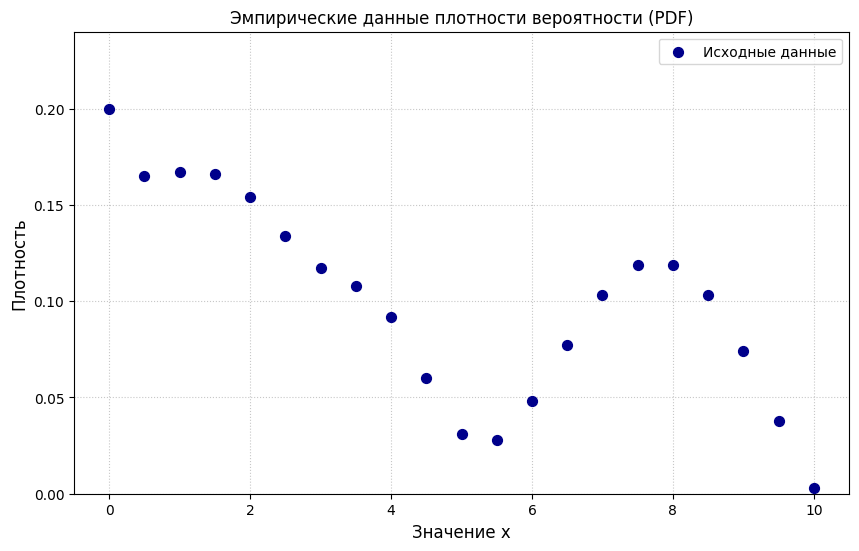

In [13]:
# Заданные точки данных (x, y), представляющие эмпирическую PDF
xs_interp = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 
                      5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0])
ys_interp = np.array([0.2, 0.165, 0.167, 0.166, 0.154, 0.134, 0.117, 
                      0.108, 0.092, 0.06, 0.031, 0.028, 0.048, 0.077, 
                      0.103, 0.119, 0.119, 0.103, 0.074, 0.038, 0.003])

plt.figure(figsize=(10, 6))
plt.scatter(xs_interp, ys_interp, color='darkblue', s=50, zorder=5, label='Исходные данные')

plt.title('Эмпирические данные плотности вероятности (PDF)')
plt.xlabel('Значение x', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.grid(ls=':', alpha=0.7)
plt.xlim(min(xs_interp)-0.5, max(xs_interp)+0.5)
plt.ylim(0, max(ys_interp)*1.2)
plt.legend()
plt.show()


## 1. Сравнение различных видов интерполяции

`interp1d` позволяет выбрать различные методы интерполяции (виды `kind`):
* `'linear'` (по умолчанию): линейная интерполяция между точками.
* `'nearest'`: значение берется от ближайшей точки.
* `'quadratic'`: квадратичная сплайн-интерполяция.
* `'cubic'`: кубическая сплайн-интерполяция (часто дает более гладкие результаты).

Сравним, как эти методы аппроксимируют исходные данные.

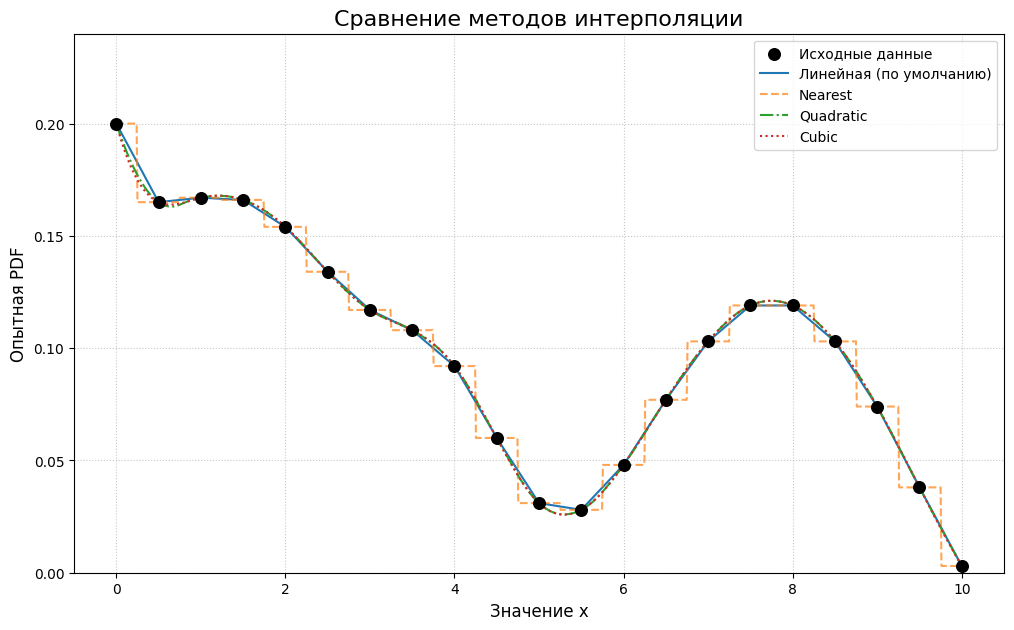

In [14]:
# Создание более плотного массива x для интерполяции
x_dense = np.linspace(min(xs_interp), max(xs_interp), 1000)

# Различные виды интерполяции
y_linear = interp1d(xs_interp, ys_interp, kind="linear")(x_dense)
y_nearest = interp1d(xs_interp, ys_interp, kind="nearest")(x_dense)
y_quadratic = interp1d(xs_interp, ys_interp, kind="quadratic")(x_dense)
y_cubic = interp1d(xs_interp, ys_interp, kind="cubic")(x_dense)

plt.figure(figsize=(12, 7))
plt.scatter(xs_interp, ys_interp, s=70, label="Исходные данные", color='black', zorder=5)
plt.plot(x_dense, y_linear, label="Линейная (по умолчанию)", linewidth=1.5, linestyle='-')
plt.plot(x_dense, y_nearest, label="Nearest", linewidth=1.5, linestyle='--', alpha=0.7)
plt.plot(x_dense, y_quadratic, label="Quadratic", linewidth=1.5, linestyle='-.')
plt.plot(x_dense, y_cubic, label="Cubic", linewidth=1.5, linestyle=':')

plt.title('Сравнение методов интерполяции', fontsize=16)
plt.xlabel('Значение x', fontsize=12)
plt.ylabel('Опытная PDF', fontsize=12)
plt.legend(fontsize=10)
plt.grid(ls=':', alpha=0.7)
plt.xlim(min(xs_interp)-0.5, max(xs_interp)+0.5)
plt.ylim(0, max(ys_interp)*1.2)
plt.show()


## 2. Вычисление вероятности и CDF с помощью интерполяции и интегрирования

Используя интерполированную функцию, можно вычислить вероятность попадания значения в любой интервал $[a, b]$ путем интегрирования PDF. Для этого нам понадобится `scipy.integrate`. Наиболее подходящие методы для численного интегрирования:

* `scipy.integrate.trapz`: для низкой точности, но высокой скорости (метод трапеций).
* `scipy.integrate.simpson`: для средней точности и достаточно высокой скорости (правило Симпсона).
* `scipy.integrate.quad`: для высокой точности, но низкой скорости (адаптивная квадратура, часто используется для функций, определенных аналитически).

Мы определим функции для вычисления вероятности в интервале (`get_prob`) и кумулятивной функции распределения (`get_cdf`).

Вероятность в интервале от 0.0 до 10.0: 1.0000


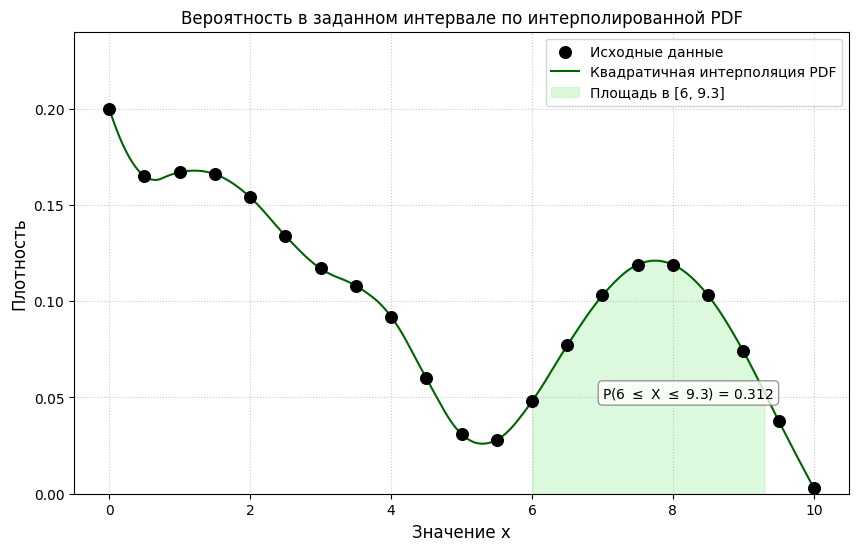

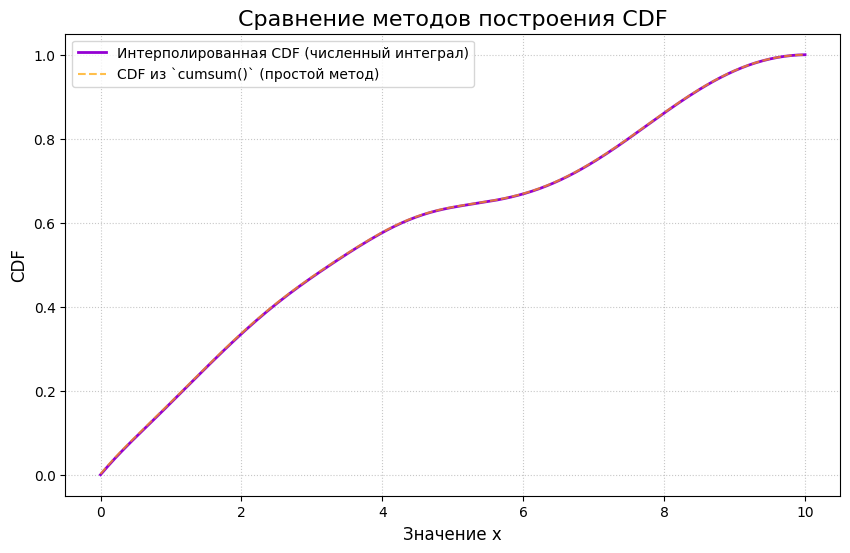

Обратите внимание: Метод CDF, реализованный через многократное интегрирование (get_cdf), является простым, но довольно медленным для большого количества точек.
Обычно следует один раз определить функцию CDF с высокой точностью и сохранить результат (например, через интерполяцию кумулятивной суммы), а затем использовать его. Пересчитывать каждый раз — неэффективно.
Для подавляющего большинства приложений метод `cumsum()` (с последующей нормализацией), примененный к достаточно плотному массиву интерполированных значений, подходит и является более быстрым.


In [15]:
# Функция для вычисления вероятности в заданном интервале
def get_prob(xs_data, ys_data, a, b, resolution=1000, kind="quadratic"):
    # Создаем интерполированную функцию из исходных данных
    interp_pdf = interp1d(xs_data, ys_data, kind=kind)

    # Нормировочный множитель (площадь под всей кривой PDF)
    x_norm = np.linspace(min(xs_data), max(xs_data), resolution)
    y_norm = interp_pdf(x_norm)
    normalisation = simpson(y_norm, x=x_norm)

    # Вычисляем площадь под кривой в заданном интервале [a, b]
    x_vals = np.linspace(a, b, resolution) # Создаем точки в заданном интервале
    y_vals = interp_pdf(x_vals)
    # Интегрируем и делим на нормализующий множитель, чтобы получить вероятность
    return simpson(y_vals, x=x_vals) / normalisation

# Функция для вычисления CDF в точке v
def get_cdf(xs_data, ys_data, v, resolution=1000, kind="quadratic"):
    # CDF в точке v - это вероятность от минимума данных до v
    return get_prob(xs_data, ys_data, min(xs_data), v, resolution=resolution, kind=kind)

print(f"Вероятность в интервале от {min(xs_interp)} до {max(xs_interp)}: {get_prob(xs_interp, ys_interp, min(xs_interp), max(xs_interp)):.4f}")

# Пример вычисления вероятности в произвольном интервале
v1, v2 = 6, 9.3
area_calculated = get_prob(xs_interp, ys_interp, v1, v2)

plt.figure(figsize=(10, 6))
plt.scatter(xs_interp, ys_interp, s=70, label="Исходные данные", color='black', zorder=5)
plt.plot(x_dense, y_quadratic, linestyle="-", color='darkgreen', label="Квадратичная интерполяция PDF")

# Закрашиваем область под графиком в интервале [v1, v2]
plt.fill_between(x_dense, 0, y_quadratic, where=(x_dense >= v1) & (x_dense <= v2),
                 alpha=0.3, color='lightgreen', label=f'Площадь в [{v1}, {v2}]')

plt.annotate(rf"P({v1} $\leq$ X $\leq$ {v2}) = {area_calculated:.3f}", (7, 0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.title('Вероятность в заданном интервале по интерполированной PDF')
plt.xlabel('Значение x', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(ls=':', alpha=0.7)
plt.xlim(min(xs_interp)-0.5, max(xs_interp)+0.5)
plt.ylim(0, max(ys_interp)*1.2)
plt.show()

# Построение интерполированной CDF
x_new_cdf = np.linspace(min(xs_interp), max(xs_interp), 200) # Точки для построения CDF
cdf_interpolated = [get_cdf(xs_interp, ys_interp, i) for i in x_new_cdf]

# Также можно получить CDF простым кумулятивным суммированием интерполированных значений
cdf_simple_from_interp = y_quadratic.cumsum() / y_quadratic.sum()

plt.figure(figsize=(10, 6))
plt.plot(x_new_cdf, cdf_interpolated, label="Интерполированная CDF (численный интеграл)", 
         color='darkviolet', linewidth=2)
plt.plot(x_dense, cdf_simple_from_interp, label="CDF из `cumsum()` (простой метод)", 
         color='orange', linestyle='--', alpha=0.7)

plt.title('Сравнение методов построения CDF', fontsize=16)
plt.ylabel('CDF', fontsize=12)
plt.xlabel('Значение x', fontsize=12)
plt.legend(loc='upper left')
plt.grid(ls=':', alpha=0.7)
plt.xlim(min(xs_interp)-0.5, max(xs_interp)+0.5)
plt.ylim(-0.05, 1.05)
plt.show()

print("Обратите внимание: Метод CDF, реализованный через многократное интегрирование (get_cdf), является простым, но довольно медленным для большого количества точек.")
print("Обычно следует один раз определить функцию CDF с высокой точностью и сохранить результат (например, через интерполяцию кумулятивной суммы), а затем использовать его. Пересчитывать каждый раз — неэффективно.")
print("Для подавляющего большинства приложений метод `cumsum()` (с последующей нормализацией), примененный к достаточно плотному массиву интерполированных значений, подходит и является более быстрым.")


## 3. Пользовательские распределения на основе класса `rv_continuous`

`scipy.stats` позволяет создавать пользовательские непрерывные распределения, наследуясь от класса `sst.rv_continuous` и переопределяя метод `_pdf` (для плотности вероятности) и, опционально, другие методы (`_cdf`, `_ppf`, `_rvs`). Это дает возможность работать с произвольными функциями как с полноценными статистическими распределениями.

Рассмотрим пример произвольной функции:
$$ f(x) = e^{(x+10.5)^{0.1}} + \frac{\sin(x)}{x+1} + \cos^2(2.5 x^{0.5}) $$
на интервале $[1, 10]$.

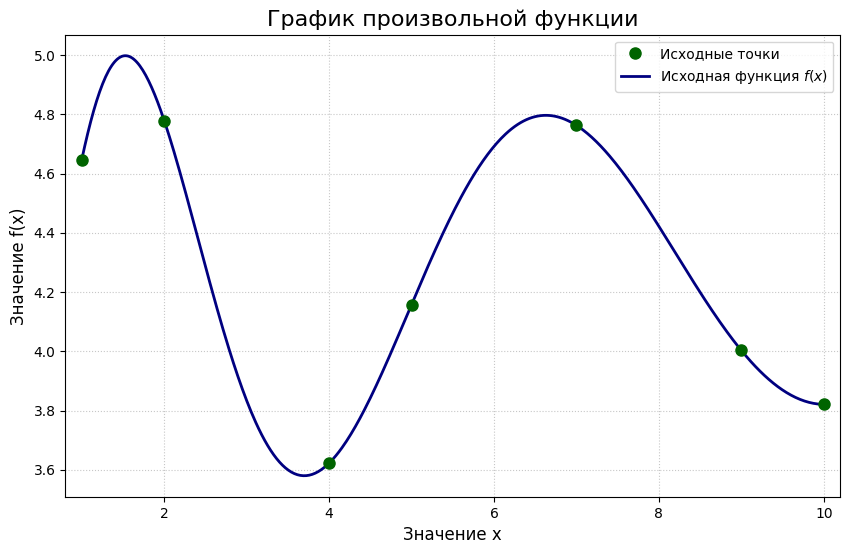

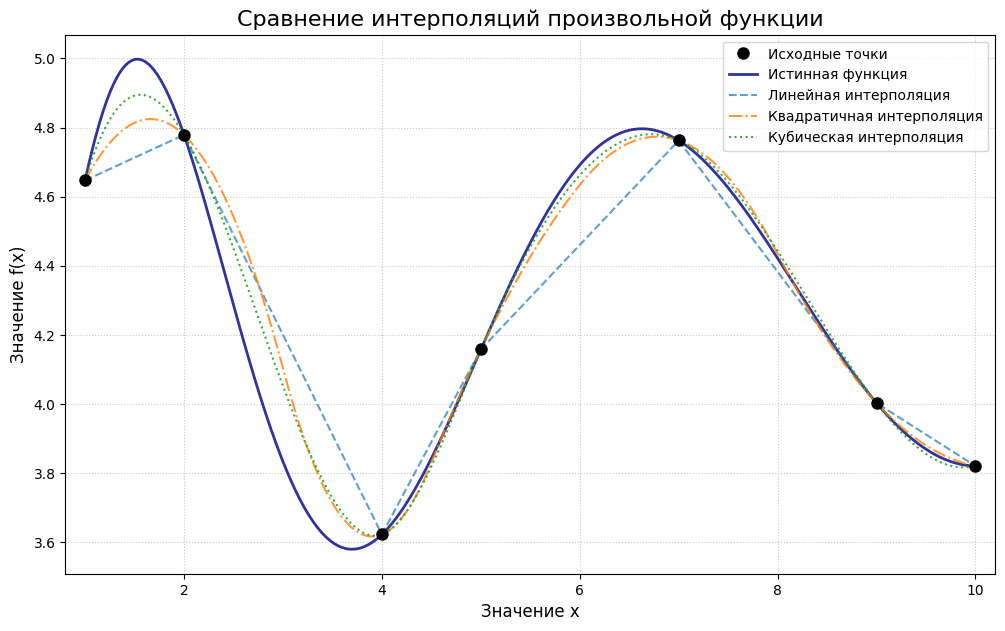

In [16]:
# Произвольная функция, которую мы хотим использовать как PDF
def custom_fn_pdf(xs):
    return np.exp((xs + 10.5)**0.1) + np.sin(xs) / (xs + 1) + np.cos(2.5 * xs**0.5)**2

# Создание точек для демонстрации исходной функции
xs_orig = np.array([1, 2, 4, 5, 7, 9, 10])
ys_orig = custom_fn_pdf(xs_orig)

# Более плотный массив x для построения гладкой кривой функции
x_fine_plot = np.linspace(1, 10, 500)
y_fine_plot = custom_fn_pdf(x_fine_plot)

plt.figure(figsize=(10, 6))
plt.plot(xs_orig, ys_orig, 'o', label="Исходные точки", markersize=8, color='darkgreen', zorder=5)
plt.plot(x_fine_plot, y_fine_plot, label="Исходная функция $f(x)$", color='navy', linewidth=2)

plt.title('График произвольной функции', fontsize=16)
plt.xlabel('Значение x', fontsize=12)
plt.ylabel('Значение f(x)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(ls=':', alpha=0.7)
plt.xlim(0.8, 10.2)
plt.show()

# Сравнение интерполяций с исходной функцией
y_linear_fn = interp1d(xs_orig, ys_orig, kind="linear")(x_fine_plot)
y_quadratic_fn = interp1d(xs_orig, ys_orig, kind="quadratic")(x_fine_plot)
y_cubic_fn = interp1d(xs_orig, ys_orig, kind="cubic")(x_fine_plot)

plt.figure(figsize=(12, 7))
plt.plot(xs_orig, ys_orig, 'o', label="Исходные точки", markersize=8, color='black', zorder=5)
plt.plot(x_fine_plot, y_fine_plot, label="Истинная функция", color='navy', linewidth=2, alpha=0.8)
plt.plot(x_fine_plot, y_linear_fn, label="Линейная интерполяция", linestyle='--', alpha=0.7)
plt.plot(x_fine_plot, y_quadratic_fn, label="Квадратичная интерполяция", linestyle='-.', alpha=0.8)
plt.plot(x_fine_plot, y_cubic_fn, label="Кубическая интерполяция", linestyle=':', alpha=0.9)

plt.title('Сравнение интерполяций произвольной функции', fontsize=16)
plt.xlabel('Значение x', fontsize=12)
plt.ylabel('Значение f(x)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(ls=':', alpha=0.7)
plt.xlim(0.8, 10.2)
plt.show()


### Создание пользовательского непрерывного распределения

Теперь определим класс `empiric_gen`, наследующийся от `sst.rv_continuous`. Мы переопределяем метод `_pdf`, чтобы использовать нашу произвольную функцию. После этого мы можем сгенерировать выборку из этого "эмпирического" распределения, используя метод `rvs`.

### Статистика выборки из пользовательского распределения ###
Первые 10 значений выборки:
 [1.06323389 1.16917563 1.0705799  1.05897855 1.19575584 1.15972191
 1.09622109 1.12101464 1.19709969 1.0886213 ]
Выборочное среднее: 1.105
Выборочная дисперсия: 0.004
Стандартное отклонение: 0.061


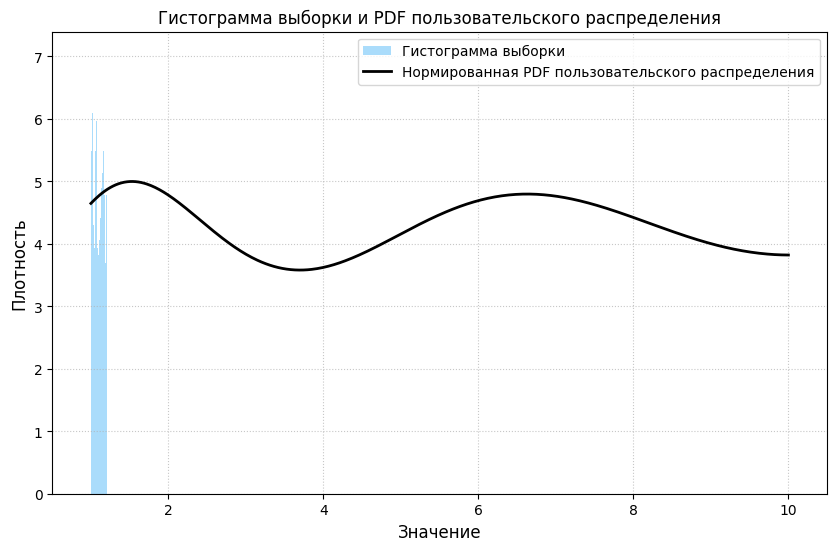

In [17]:
# Определение пользовательского непрерывного распределения
class empiric_gen(sst.rv_continuous):
    # Метод _pdf определяет форму функции плотности вероятности
    def _pdf(self, x):
        return np.exp((x + 10.5)**0.1) + np.sin(x) / (x + 1) + np.cos(2.5 * x**0.5)**2

# Создание экземпляра нашего распределения, указывая границы (a, b)
# Важно: функция _pdf не обязательно должна быть нормализована, scipy.stats сделает это автоматически при сэмплировании.
empir = empiric_gen(a=1, b=10, name='custom_empirical_distribution') # Интервал от 1 до 10

# Генерация выборки из нашего пользовательского распределения
sample_emp = empir.rvs(size=2000) # Увеличим размер выборки для лучшей аппроксимации

print('### Статистика выборки из пользовательского распределения ###')
print('Первые 10 значений выборки:\n', sample_emp[:10])
print(f'Выборочное среднее: {sample_emp.mean():.3f}')
print(f'Выборочная дисперсия: {sample_emp.var():.3f}')
print(f'Стандартное отклонение: {sample_emp.std():.3f}')

# Визуализация: гистограмма выборки и наложенная PDF
plt.figure(figsize=(10, 6))
plt.hist(sample_emp, bins=50, density=True, alpha=0.7, color='lightskyblue', label='Гистограмма выборки')

# Построение нормированной PDF
x_plot = np.linspace(empir.a, empir.b, 500)
pdf_values = empir.pdf(x_plot) # Используем empir.pdf для получения нормированной плотности
plt.plot(x_plot, pdf_values, 'k-', linewidth=2, label='Нормированная PDF пользовательского распределения')

plt.title('Гистограмма выборки и PDF пользовательского распределения')
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(ls=':', alpha=0.7)
plt.xlim(empir.a - 0.5, empir.b + 0.5)
plt.show()


### Пользовательские дискретные распределения

Для дискретных случайных величин, которые принимают небольшое число значений, можно не создавать новый класс, а явно указать эти значения и их вероятности с помощью `sst.rv_discrete`. Это удобно для табличных или категориальных данных.

### Статистика выборки из пользовательского дискретного распределения ###
Первые 20 значений выборки:
 [7 7 1 1 7 7 7 3 1 1 1 1 7 1 7 1 1 7 1 1]
Выборочное среднее: 3.065
Частота значения 1: 0.590 (ожидалось 0.6)
Частота значения 3: 0.099 (ожидалось 0.1)
Частота значения 7: 0.311 (ожидалось 0.3)


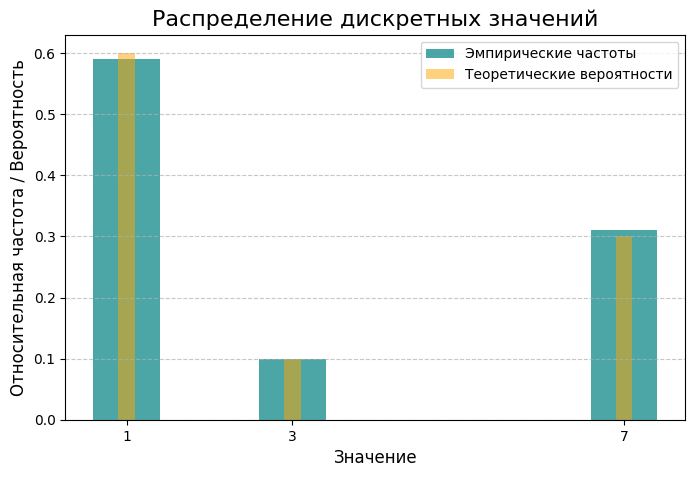

In [18]:
# Определение пользовательского дискретного распределения
some_distribution = sst.rv_discrete(
    name='my_discrete_distribution',
    values=([1, 3, 7], [0.6, 0.1, 0.3])  # Значения и соответствующие вероятности
)

# Генерация выборки из дискретного распределения
sample_discrete = some_distribution.rvs(size=5000) # Увеличим размер выборки для стабильности частот

print('### Статистика выборки из пользовательского дискретного распределения ###')
print('Первые 20 значений выборки:\n', sample_discrete[:20])
print(f'Выборочное среднее: {sample_discrete.mean():.3f}')

# Вычисление частоты каждого значения в выборке
freq_1 = (sample_discrete == 1).mean()
freq_3 = (sample_discrete == 3).mean()
freq_7 = (sample_discrete == 7).mean()
print(f'Частота значения 1: {freq_1:.3f} (ожидалось 0.6)')
print(f'Частота значения 3: {freq_3:.3f} (ожидалось 0.1)')
print(f'Частота значения 7: {freq_7:.3f} (ожидалось 0.3)')

# Визуализация: столбчатая диаграмма частот
plt.figure(figsize=(8, 5))
unique_vals, counts = np.unique(sample_discrete, return_counts=True)
plt.bar(unique_vals, counts / len(sample_discrete), color='teal', alpha=0.7, label='Эмпирические частоты')
plt.bar(some_distribution.xk, some_distribution.pk, color='orange', alpha=0.5, width=0.2, 
        label='Теоретические вероятности', align='center')

plt.title('Распределение дискретных значений', fontsize=16)
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Относительная частота / Вероятность', fontsize=12)
plt.xticks(unique_vals)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# V. Интервальная оценка выборочных данных и Центральная Предельная Теорема (ЦПТ)

**Центральная Предельная Теорема (ЦПТ)** — одно из фундаментальных положений теории вероятностей. Она утверждает, что распределение выборочных средних из любой генеральной совокупности (независимо от ее собственного распределения), если размер выборки достаточно велик, будет приближаться к нормальному распределению. Это приближение тем точнее, чем больше размер выборки.

Мы проиллюстрируем ЦПТ, смоделировав ненормальное распределение, а затем многократно взяв из него небольшие выборки и вычислив их средние. Мы увидим, как распределение этих средних будет стремиться к нормальному.

Функция `my_get_data` будет генерировать данные из "смешанного" распределения, которое не является нормальным.

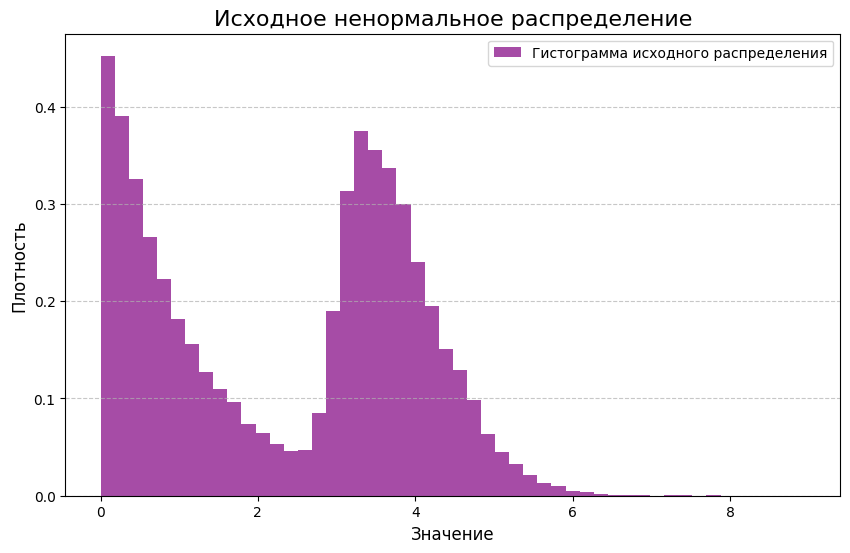

Размер исходной генеральной совокупности: 50000
Как видно из графика, это распределение определенно не является нормальным.


In [19]:
# Функция для генерации данных из ненормального распределения
def my_get_data(n):
    # Объединяем данные из экспоненциального и асимметричного нормального распределений
    data = np.concatenate(
             (sst.expon.rvs(scale=1, size=n//2),        # Экспоненциальное распределение
              sst.skewnorm.rvs(5, loc=3, size=n//2))) # Асимметричное нормальное распределение (skew=5)
    # Перемешиваем значения в массиве, чтобы избежать упорядоченности
    np.random.shuffle(data)
    return data

# Генерация и визуализация исходного ненормального распределения
n_population = 50000 # Большой размер для демонстрации формы распределения
population_data = my_get_data(n_population)

plt.figure(figsize=(10, 6))
plt.hist(population_data, bins=50, density=True, alpha=0.7, color='purple', label='Гистограмма исходного распределения')
plt.title('Исходное ненормальное распределение', fontsize=16)
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(f"Размер исходной генеральной совокупности: {n_population}")
print("Как видно из графика, это распределение определенно не является нормальным.")


## 1. Распределение средних небольших выборок

В реальных экспериментах мы часто ограничены в количестве собираемых данных. Предположим, мы можем собрать только 10 точек данных за один раз. Если мы повторим этот процесс многократно, каждый раз вычисляя среднее, то увидим, как распределение этих средних начинает принимать форму нормального распределения, согласно ЦПТ.

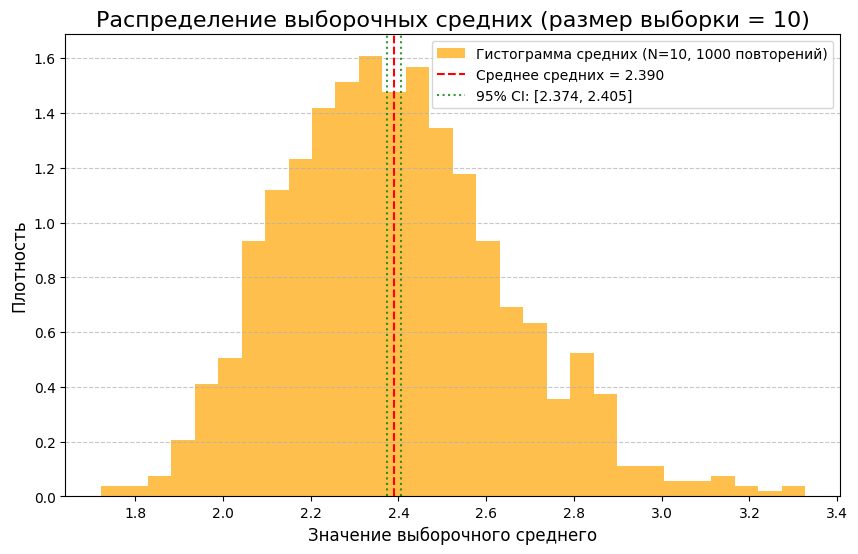

Стандартное отклонение распределения средних (N=10): 0.254
Обратите внимание: Каждый раз при запуске этого блока значения будут немного меняться,
но общая форма распределения средних будет стремиться к нормальной.


In [20]:
num_experiments_small = 1000 # Количество экспериментов (выборок средних)
sample_size_small = 10     # Размер каждой выборки

# Генерируем 1000 выборочных средних, каждая из которых основана на 10 точках
ave_means_small = [my_get_data(sample_size_small).mean() for _ in range(num_experiments_small)]

plt.figure(figsize=(10, 6))
plt.hist(ave_means_small, bins=30, density=True, alpha=0.7, color='orange', 
         label=f'Гистограмма средних (N={sample_size_small}, {num_experiments_small} повторений)')

# Вычислим доверительный интервал для средних выборок
mean_of_means = np.mean(ave_means_small)
std_err_of_means = sst.sem(ave_means_small) # Стандартная ошибка среднего
df_means = len(ave_means_small) - 1 # Степени свободы

conf_interval_small = sst.t.interval(0.95, loc=mean_of_means, df=df_means, scale=std_err_of_means)

# Нарисуем вертикальные линии для среднего и доверительного интервала
plt.axvline(mean_of_means, color='red', linestyle='--', label=f'Среднее средних = {mean_of_means:.3f}')
plt.axvline(conf_interval_small[0], color='green', linestyle=':', 
            label=f'95% CI: [{conf_interval_small[0]:.3f}, {conf_interval_small[1]:.3f}]', alpha=0.8)
plt.axvline(conf_interval_small[1], color='green', linestyle=':', alpha=0.8)

plt.title(f'Распределение выборочных средних (размер выборки = {sample_size_small})', fontsize=16)
plt.xlabel('Значение выборочного среднего', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Стандартное отклонение распределения средних (N={sample_size_small}): {np.std(ave_means_small):.3f}")
print("Обратите внимание: Каждый раз при запуске этого блока значения будут немного меняться,")
print("но общая форма распределения средних будет стремиться к нормальной.")


## 2. Влияние размера выборки на распределение средних

Согласно ЦПТ, не только форма распределения средних приближается к нормальной, но и его дисперсия уменьшается с увеличением размера выборки. Стандартное отклонение распределения выборочных средних (также известное как стандартная ошибка среднего) равно $\sigma / \sqrt{N}$, где $\sigma$ — стандартное отклонение генеральной совокупности, а $N$ — размер выборки.

Это означает, что для увеличения точности оценки среднего в 2 раза, необходимо увеличить размер выборки в 4 раза.

Проверим это утверждение, увеличив размер каждой выборки до 100 точек.

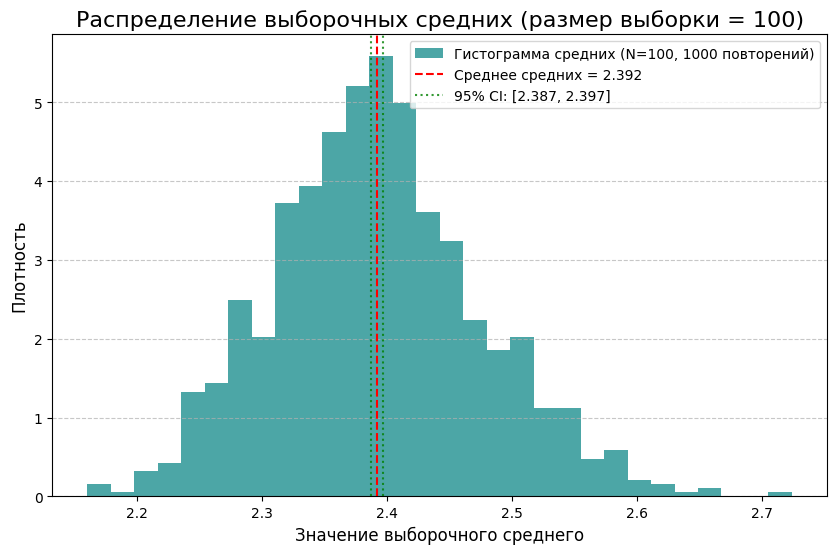

Стандартное отклонение распределения средних (N=100): 0.083
Это распределение выглядит более гауссовым, и его дисперсия заметно меньше, чем в предыдущем случае.


In [21]:
num_experiments_large = 1000 # Количество экспериментов
sample_size_large = 100    # Увеличенный размер каждой выборки

# Генерируем 1000 выборочных средних, каждая из которых основана на 100 точках
ave_means_large = [my_get_data(sample_size_large).mean() for _ in range(num_experiments_large)]

plt.figure(figsize=(10, 6))
plt.hist(ave_means_large, bins=30, density=True, alpha=0.7, color='teal', 
         label=f'Гистограмма средних (N={sample_size_large}, {num_experiments_large} повторений)')

# Вычислим и отобразим доверительный интервал
mean_of_means_large = np.mean(ave_means_large)
std_err_of_means_large = sst.sem(ave_means_large)
df_means_large = len(ave_means_large) - 1

conf_interval_large = sst.t.interval(0.95, loc=mean_of_means_large, df=df_means_large, scale=std_err_of_means_large)

plt.axvline(mean_of_means_large, color='red', linestyle='--', label=f'Среднее средних = {mean_of_means_large:.3f}')
plt.axvline(conf_interval_large[0], color='green', linestyle=':', 
            label=f'95% CI: [{conf_interval_large[0]:.3f}, {conf_interval_large[1]:.3f}]', alpha=0.8)
plt.axvline(conf_interval_large[1], color='green', linestyle=':', alpha=0.8)

plt.title(f'Распределение выборочных средних (размер выборки = {sample_size_large})', fontsize=16)
plt.xlabel('Значение выборочного среднего', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Стандартное отклонение распределения средних (N={sample_size_large}): {np.std(ave_means_large):.3f}")
print("Это распределение выглядит более гауссовым, и его дисперсия заметно меньше, чем в предыдущем случае.")


## 3. Зависимость стандартного отклонения средних от размера выборки

Продемонстрируем зависимость стандартного отклонения выборочных средних от размера выборки $N$. Мы ожидаем увидеть соответствие теоретической зависимости $\sigma_{mean} = \sigma_{pop} / \sqrt{N}$.

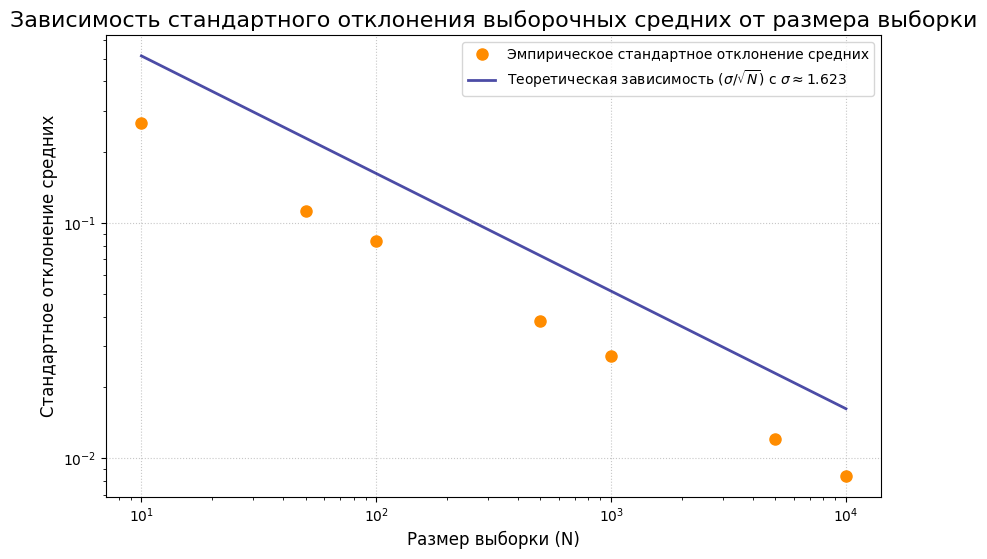

На этом графике видно, что эмпирические стандартные отклонения средних хорошо аппроксимируются функцией $1/\sqrt{N}$, что подтверждает Центральную Предельную Теорему.
Это означает, что для увеличения точности оценки среднего в $k$ раз, необходимо увеличить количество данных в $k^2$ раз.


In [22]:
# Различные размеры выборок для анализа
num_samps_list = [10, 50, 100, 500, 1000, 5000, 10000]
num_repetitions = 1000 # Количество повторений для каждой размерности выборки

my_stds_of_means = []
for n_size in num_samps_list:
    # Для каждого размера выборки n_size, генерируем num_repetitions средних
    means_for_n = [my_get_data(n_size).mean() for _ in range(num_repetitions)]
    # Вычисляем стандартное отклонение этих средних
    my_stds_of_means.append(np.std(means_for_n))

# Оценка стандартного отклонения исходной генеральной совокупности
true_std_population = np.std(my_get_data(50000)) # Используем большую выборку для оценки истинной сигмы

plt.figure(figsize=(10, 6))
plt.plot(num_samps_list, my_stds_of_means, 'o', label="Эмпирическое стандартное отклонение средних", 
         color='darkorange', markersize=8, zorder=5)

# Построение теоретической аппроксимации: sigma_population / sqrt(N)
theoretical_std_curve = true_std_population / np.sqrt(num_samps_list)
plt.plot(num_samps_list, theoretical_std_curve, 
         label=fr'Теоретическая зависимость ($\sigma / \sqrt{{N}}$) с $\sigma \approx {true_std_population:.3f}$',
         color='navy', linestyle='-', linewidth=2, alpha=0.7)

plt.title('Зависимость стандартного отклонения выборочных средних от размера выборки', fontsize=16)
plt.xlabel('Размер выборки (N)', fontsize=12)
plt.ylabel('Стандартное отклонение средних', fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(ls=':', alpha=0.7)
plt.show()

print(r"На этом графике видно, что эмпирические стандартные отклонения средних хорошо аппроксимируются функцией $1/\sqrt{N}$, что подтверждает Центральную Предельную Теорему.")
print(r"Это означает, что для увеличения точности оценки среднего в $k$ раз, необходимо увеличить количество данных в $k^2$ раз.")


## 4. Оценка среднего и его неопределенности

Когда мы получаем одну большую выборку, мы можем оценить ее среднее значение и неопределенность этого среднего, используя стандартную ошибку среднего ($SEM = \sigma / \sqrt{N}$). Это позволяет нам построить доверительный интервал для истинного среднего генеральной совокупности.

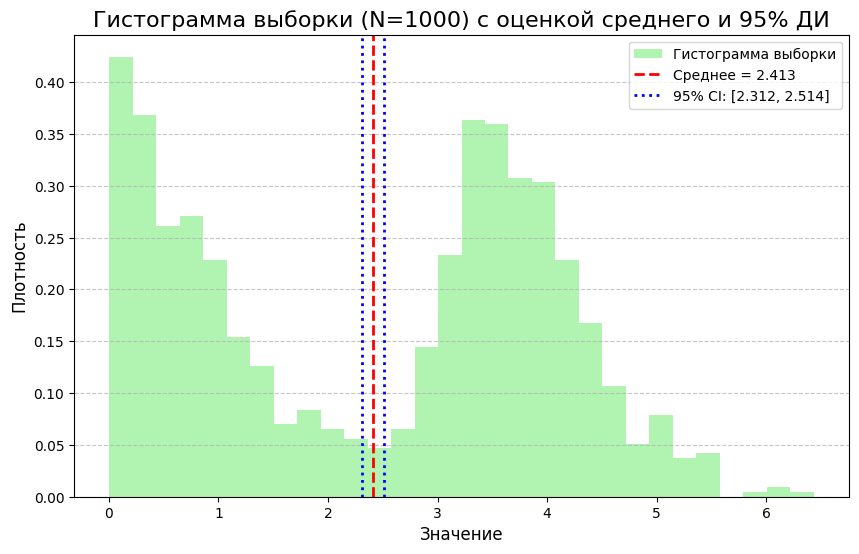

Оценка среднего значения генеральной совокупности: 2.413 $\pm$ 0.051
Наличие знака $\pm$ отражает неопределенность оценки среднего, которая уменьшается с увеличением размера выборки, и распределяется по нормальному закону (благодаря ЦПТ).


In [23]:
n_final_sample = 1000 # Размер одной большой выборки
data_single_sample = my_get_data(n_final_sample)

sample_mean = np.mean(data_single_sample)
sample_std = np.std(data_single_sample, ddof=1) # Несмещенное стандартное отклонение выборки
uncert_mean = sst.sem(data_single_sample) # Стандартная ошибка среднего (SEM)

# Вычислим 95%-й доверительный интервал для среднего
# sst.t.interval(confidence, df, loc, scale)
# loc = выборочное среднее, scale = стандартная ошибка среднего
conf_interval_final = sst.t.interval(0.95, loc=sample_mean, df=n_final_sample - 1, scale=uncert_mean)

plt.figure(figsize=(10, 6))
plt.hist(data_single_sample, bins=30, density=True, alpha=0.7, color='lightgreen', label='Гистограмма выборки')

# Нарисуем вертикальные линии для среднего и границ доверительного интервала
plt.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label=f'Среднее = {sample_mean:.3f}')
plt.axvline(conf_interval_final[0], color='blue', linestyle=':', linewidth=2, 
            label=f'95% CI: [{conf_interval_final[0]:.3f}, {conf_interval_final[1]:.3f}]')
plt.axvline(conf_interval_final[1], color='blue', linestyle=':', linewidth=2)

plt.title(f'Гистограмма выборки (N={n_final_sample}) с оценкой среднего и 95% ДИ', fontsize=16)
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Оценка среднего значения генеральной совокупности: {sample_mean:.3f} $\\pm$ {uncert_mean:.3f}")
print("Наличие знака $\\pm$ отражает неопределенность оценки среднего, которая уменьшается с увеличением размера выборки, и распределяется по нормальному закону (благодаря ЦПТ).")


# VI. Непараметрические критерии

Непараметрические критерии не делают строгих предположений о форме распределения данных. Они особенно полезны, когда данные не соответствуют нормальному распределению или когда размер выборки слишком мал для применения параметрических тестов.

## 1. Критерий согласия Колмогорова-Смирнова (`kstest`, `ks_2samp`)

Критерий Колмогорова-Смирнова (КС-тест) используется для проверки гипотезы о том, что выборка происходит из определенного теоретического распределения (`kstest`) или что две выборки происходят из одного и того же распределения (`ks_2samp`). Он чувствителен к различиям в медиане, дисперсии и форме распределения.

**Важное примечание:** КС-тест предназначен для *непрерывных* распределений. Хотя его можно применять к дискретным данным, интерпретация может быть менее прямой, и для дискретных данных существуют более подходящие тесты (например, хи-квадрат).

Для демонстрации `ks_2samp` мы сгенерируем две "смещенные" дискретные выборки, имитирующие результаты бросков кубиков с небольшим смещением.

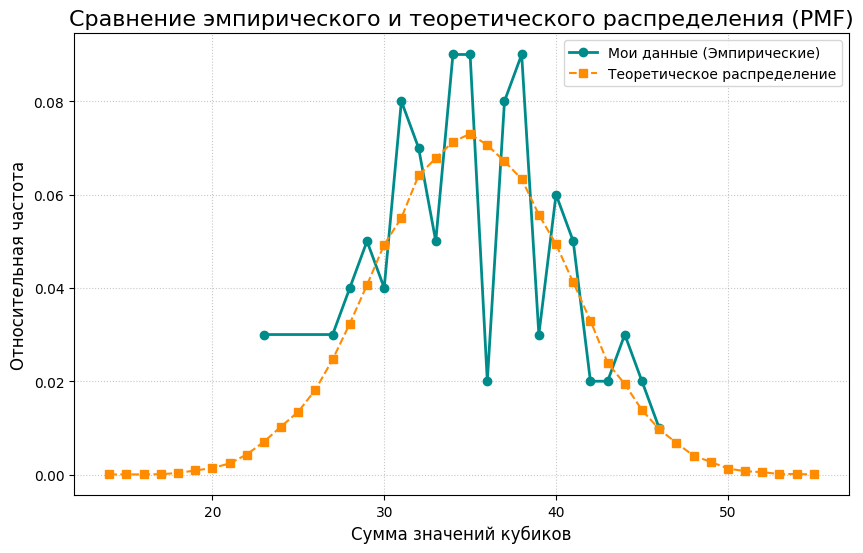

/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_32803/2923449277.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([r_obs, r_fair], vert=False, patch_artist=True,


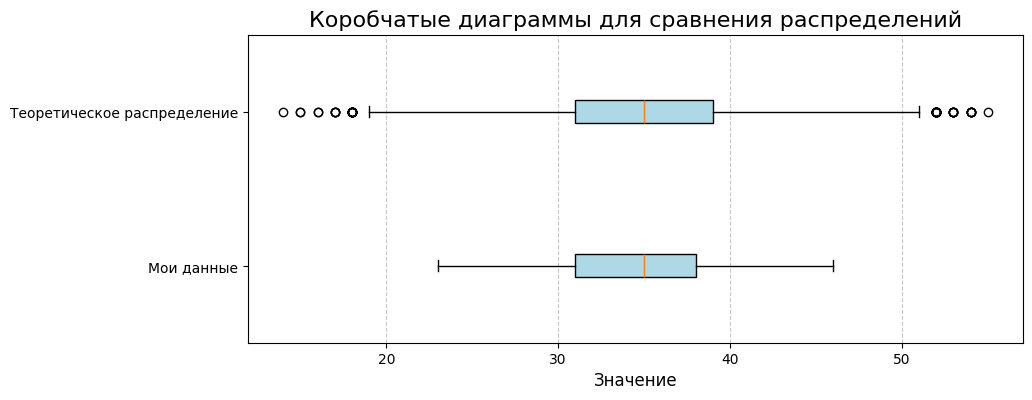

Набор данных 'Мои данные' выглядит довольно беспорядочно по сравнению с 'Теоретическим распределением'.
Сравнение по PDF/PMF (гистограммам) может быть трудным, особенно при малом количестве данных.
В таких случаях построение кумулятивной функции распределения (CDF) более информативно, так как оно не требует разбиения данных на интервалы.


In [24]:
# Генерация "смещенного" распределения (имитация бросков 10 кубиков + небольшое смещение)
np.random.seed(42) # Для воспроизводимости
r_obs = np.random.randint(1, 7, size=(100, 10)).sum(axis=1) + np.random.choice([0, 1, 2], p=[0.7, 0.2, 0.1], size=100)

# Генерация "справедливого" (теоретического) распределения (большая выборка)
r_fair = np.random.randint(1, 7, size=(50000, 10)).sum(axis=1)

# Получение уникальных значений и их относительных частот для визуализации PDF/PMF
unique_obs, count_obs = np.unique(r_obs, return_counts=True)
count_obs = count_obs / count_obs.sum()

unique_fair, count_fair = np.unique(r_fair, return_counts=True)
count_fair = count_fair / count_fair.sum()

plt.figure(figsize=(10, 6))
plt.plot(unique_obs, count_obs, 'o-', color='darkcyan', linewidth=2, label="Мои данные (Эмпирические)")
plt.plot(unique_fair, count_fair, 's--', color='darkorange', linewidth=1.5, label="Теоретическое распределение")

plt.title("Сравнение эмпирического и теоретического распределения (PMF)", fontsize=16)
plt.xlabel("Сумма значений кубиков", fontsize=12)
plt.ylabel("Относительная частота", fontsize=12)
plt.legend(loc='upper right')
plt.grid(ls=':', alpha=0.7)
plt.show()

# Коробчатая диаграмма для отображения распределения (как в исходном коде)
plt.figure(figsize=(10, 4))
plt.boxplot([r_obs, r_fair], vert=False, patch_artist=True,
            labels=['Мои данные', 'Теоретическое распределение'],
            boxprops=dict(facecolor='lightblue'))
plt.title('Коробчатые диаграммы для сравнения распределений', fontsize=16)
plt.xlabel('Значение', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Набор данных 'Мои данные' выглядит довольно беспорядочно по сравнению с 'Теоретическим распределением'.")
print("Сравнение по PDF/PMF (гистограммам) может быть трудным, особенно при малом количестве данных.")
print("В таких случаях построение кумулятивной функции распределения (CDF) более информативно, так как оно не требует разбиения данных на интервалы.")


## 2. Сравнение распределений по CDF

Построим эмпирические и теоретические CDF для наших двух выборок. Различия между этими кривыми являются основой для D-статистики Колмогорова-Смирнова.

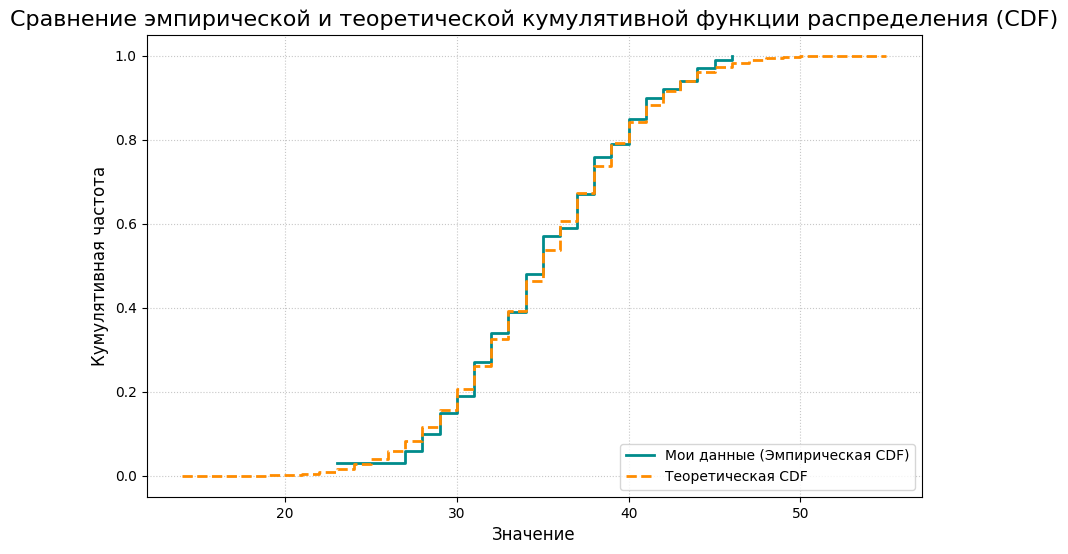

In [25]:
# Вычисление кумулятивных частот для получения эмпирических CDF
cdf_obs = count_obs.cumsum()
cdf_fair = count_fair.cumsum()

plt.figure(figsize=(10, 6))
plt.step(unique_obs, cdf_obs, where='post', color='darkcyan', linewidth=2, label="Мои данные (Эмпирическая CDF)")
plt.step(unique_fair, cdf_fair, where='post', color='darkorange', linewidth=2, linestyle='--', label="Теоретическая CDF")

plt.title("Сравнение эмпирической и теоретической кумулятивной функции распределения (CDF)", fontsize=16)
plt.xlabel("Значение", fontsize=12)
plt.ylabel("Кумулятивная частота", fontsize=12)
plt.legend(loc='lower right')
plt.grid(ls=':', alpha=0.7)
plt.ylim(-0.05, 1.05)
plt.show()


## 3. Применение КС-теста

### `sst.ks_2samp(sample1, sample2)`

Проверяет, происходят ли две выборки из одного и того же непрерывного распределения.
Нулевая гипотеза ($H_0$): Две выборки взяты из одной и той же генеральной совокупности.

### `sst.kstest(sample, cdf, args=())`

Проверяет, происходит ли выборка из заданного теоретического распределения (`cdf`). Параметр `args` используется для передачи параметров теоретического распределения (например, среднего и стандартного отклонения для нормального распределения).

### Тест Колмогорова-Смирнова (ks_2samp) для двух выборок ###
Для выборок 'Мои данные' и 'Теоретическое': KS-статистика = 0.033, p-значение = 1.000
  -> Не отвергаем H0: нет статистически значимых различий между распределениями.

### Тест Колмогорова-Смирнова (kstest) для выборки и теоретических распределений ###
Для 'Моих данных' vs Равномерное: KS-статистика = 0.161, p-значение = 0.010
  -> Отвергаем H0: 'Мои данные' не соответствуют равномерному распределению.
Для 'Моих данных' vs Нормальное: KS-статистика = 0.066, p-значение = 0.750
  -> Не отвергаем H0: 'Мои данные' соответствуют нормальному распределению.


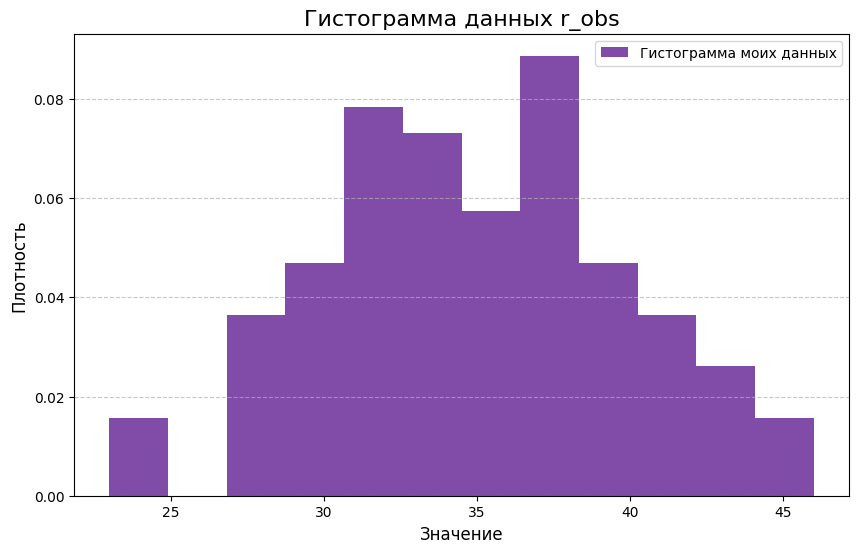

In [26]:
alpha = 0.05 # Уровень значимости

print("### Тест Колмогорова-Смирнова (ks_2samp) для двух выборок ###")
# Проверка распределений двух выборок: r_obs и r_fair
statistic_ks_2samp, pvalue_ks_2samp = sst.ks_2samp(r_obs, r_fair)
print(f"Для выборок 'Мои данные' и 'Теоретическое': KS-статистика = {statistic_ks_2samp:.3f}, p-значение = {pvalue_ks_2samp:.3f}")
if pvalue_ks_2samp < alpha:
    print("  -> Отвергаем H0: распределения статистически значимо различаются.")
else:
    print("  -> Не отвергаем H0: нет статистически значимых различий между распределениями.")

print("\n### Тест Колмогорова-Смирнова (kstest) для выборки и теоретических распределений ###")
# Проверка распределения r_obs против равномерного распределения
stats_uniform, pval_uniform = sst.kstest(r_obs, cdf=sst.uniform.cdf, args=(np.min(r_obs), np.max(r_obs)-np.min(r_obs)))
print(f"Для 'Моих данных' vs Равномерное: KS-статистика = {stats_uniform:.3f}, p-значение = {pval_uniform:.3f}")
if pval_uniform < alpha:
    print("  -> Отвергаем H0: 'Мои данные' не соответствуют равномерному распределению.")
else:
    print("  -> Не отвергаем H0: 'Мои данные' соответствуют равномерному распределению.")

# Проверка распределения r_obs против нормального распределения (с оцененными параметрами)
mean_obs = np.mean(r_obs)
std_obs = np.std(r_obs)
stats_norm, pval_norm = sst.kstest(r_obs, cdf=sst.norm.cdf, args=(mean_obs, std_obs))
print(f"Для 'Моих данных' vs Нормальное: KS-статистика = {stats_norm:.3f}, p-значение = {pval_norm:.3f}")
if pval_norm < alpha:
    print("  -> Отвергаем H0: 'Мои данные' не соответствуют нормальному распределению.")
else:
    print("  -> Не отвергаем H0: 'Мои данные' соответствуют нормальному распределению.")

# Визуализация гистограммы r_obs
plt.figure(figsize=(10, 6))
plt.hist(r_obs, bins=12, density=True, alpha=0.7, color='indigo', label='Гистограмма моих данных')
plt.title('Гистограмма данных r_obs', fontsize=16)
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Удобная функция для визуализации КС-теста

Создадим функцию `apply_kstest`, которая не только выполняет тест, но и визуализирует эмпирическую и теоретическую CDF, что позволяет наглядно оценить степень соответствия распределений. Это особенно полезно для понимания D-статистики КС-теста (максимальное вертикальное расстояние между двумя CDF).

Обратите внимание: Критерий Колмогорова-Смирнова менее чувствителен к различиям в "хвостах" распределений, чем в центральной части.


Результаты теста Колмогорова-Смирнова для Нормальное распределение (истинное нормальное):
  Статистика D = 0.0666
  p-значение = 0.7412
  -> Не отвергаем H0: выборка соответствует Нормальное распределение.


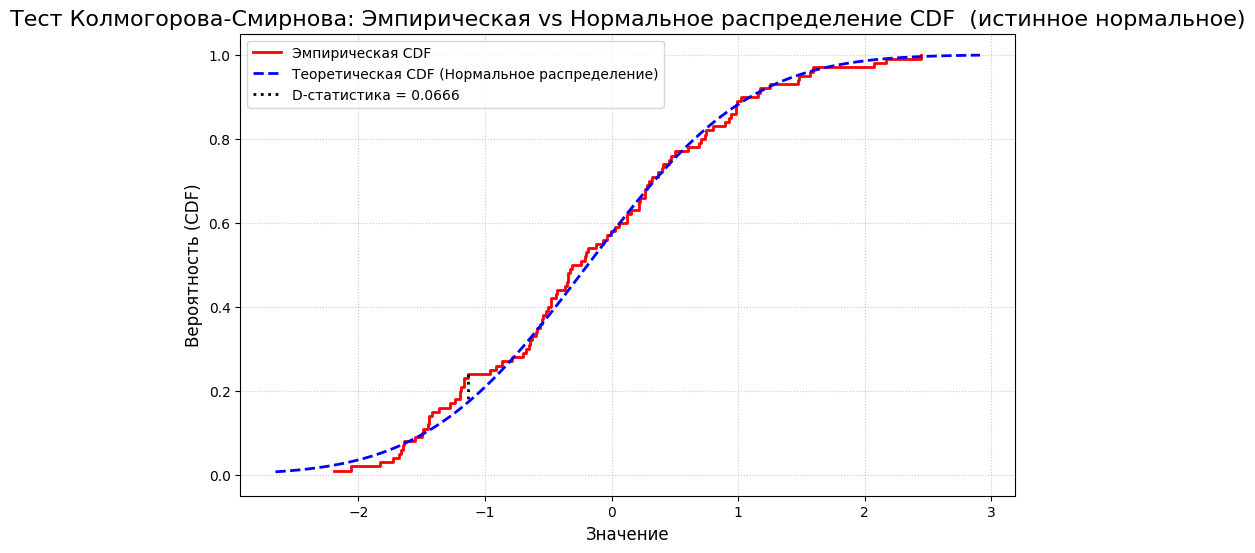


Результаты теста Колмогорова-Смирнова для Нормальное распределение (распределение Коши):
  Статистика D = 0.3713
  p-значение = 0.0000
  -> Отвергаем H0: выборка не соответствует Нормальное распределение.


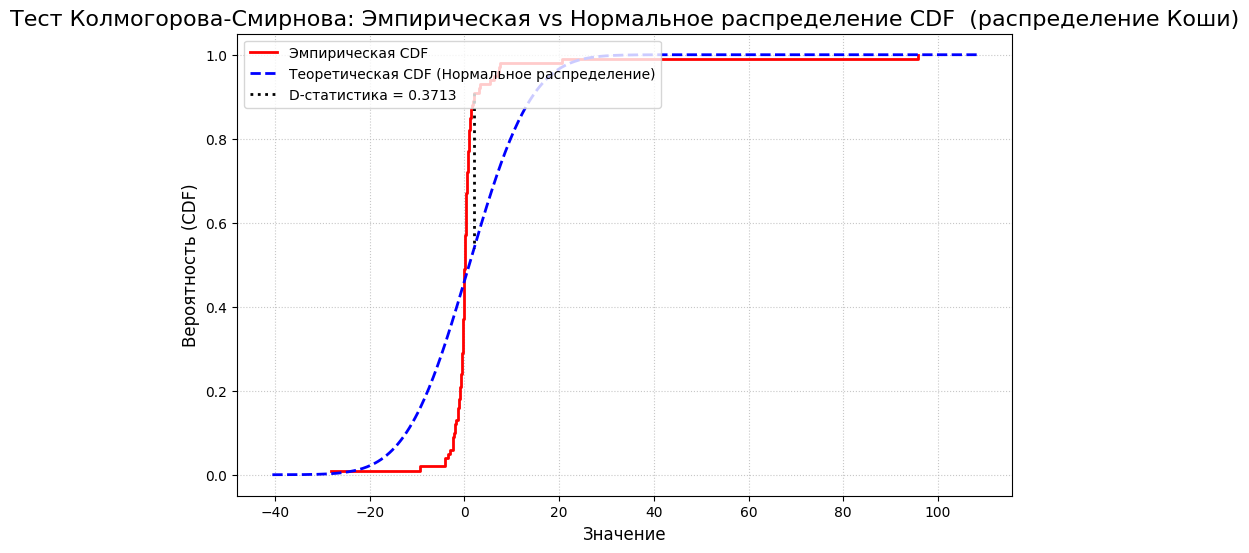

Обратите внимание, что для распределения Коши, которое имеет 'тяжелые хвосты', KS-тест может быть менее чувствителен к этим хвостам, чем к центральной части распределения.


In [27]:
def apply_kstest_with_plot(sample, cdf_func=sst.norm.cdf, cdf_name='Нормальное распределение', args=(), title_suffix=''):
    """
    Применяет тест Колмогорова-Смирнова и визуализирует эмпирическую и теоретическую CDF.

    Parameters:
    - sample (np.array): Выборка данных.
    - cdf_func (function): Теоретическая CDF функция (например, sst.norm.cdf).
    - cdf_name (str): Название теоретического распределения для легенды.
    - args (tuple): Параметры для теоретической CDF (например, (mean, std) для нормального).
    - title_suffix (str): Дополнительный текст для заголовка графика.
    """
    # Выполняем KS-тест
    ks_statistic, p_value = sst.kstest(sample, cdf=cdf_func, args=args)
    
    print(f"\nРезультаты теста Колмогорова-Смирнова для {cdf_name}{title_suffix}:")
    print(f"  Статистика D = {ks_statistic:.4f}")
    print(f"  p-значение = {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"  -> Отвергаем H0: выборка не соответствует {cdf_name}.")
    else:
        print(f"  -> Не отвергаем H0: выборка соответствует {cdf_name}.")

    plt.figure(figsize=(10, 6))
    
    # Эмпирическая CDF (ECDF)
    x_sorted = np.sort(sample)
    # Делаем ECDF ступенчатой функцией, чтобы она выглядела корректно для дискретных/пошаговых данных
    y_ecdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    plt.step(x_sorted, y_ecdf, where='post', color='red', linewidth=2, label='Эмпирическая CDF')

    # Теоретическая CDF
    # Расширяем диапазон для теоретической CDF, чтобы она охватывала весь график
    min_val, max_val = np.min(sample), np.max(sample)
    grid = np.linspace(min_val - (max_val - min_val) * 0.1, max_val + (max_val - min_val) * 0.1, 500)
    theoretical_cdf_values = cdf_func(grid, *args)
    plt.plot(grid, theoretical_cdf_values, color='blue', linewidth=2, linestyle='--', label=f'Теоретическая CDF ({cdf_name})')
    
    # Визуализация D-статистики (максимальное вертикальное расстояние)
    # Находим индекс, где разница между ECDF и теоретической CDF максимальна
    # Нужно вычислить теоретическую CDF на точках ECDF для точного сравнения
    theoretical_cdf_at_ecdf_points = cdf_func(x_sorted, *args)
    max_diff_idx = np.argmax(np.abs(y_ecdf - theoretical_cdf_at_ecdf_points))
    
    plt.plot([x_sorted[max_diff_idx], x_sorted[max_diff_idx]],
             [y_ecdf[max_diff_idx], theoretical_cdf_at_ecdf_points[max_diff_idx]],
             'k:', linewidth=2, label=f'D-статистика = {ks_statistic:.4f}')

    plt.title(f'Тест Колмогорова-Смирнова: Эмпирическая vs {cdf_name} CDF {title_suffix}', fontsize=16)
    plt.xlabel('Значение', fontsize=12)
    plt.ylabel('Вероятность (CDF)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(ls=':', alpha=0.7)
    plt.ylim(-0.05, 1.05)
    plt.show()

# Пример использования: проверка нормальности для нормально распределенной выборки
sample_normal = sst.norm.rvs(size=100)
apply_kstest_with_plot(sample_normal, cdf_func=sst.norm.cdf, cdf_name='Нормальное распределение',
                      args=(np.mean(sample_normal), np.std(sample_normal)), title_suffix=' (истинное нормальное)')

# Пример использования: проверка нормальности для распределения Коши (с тяжелыми хвостами)
sample_cauchy = sst.cauchy.rvs(size=100)
apply_kstest_with_plot(sample_cauchy, cdf_func=sst.norm.cdf, cdf_name='Нормальное распределение',
                      args=(np.mean(sample_cauchy), np.std(sample_cauchy)), title_suffix=' (распределение Коши)')
print("Обратите внимание, что для распределения Коши, которое имеет 'тяжелые хвосты', KS-тест может быть менее чувствителен к этим хвостам, чем к центральной части распределения.")


## 4. Тест Пирсона $\chi^2$ (Хи-квадрат) (`chisquare`)

Тест Пирсона $\chi^2$ (хи-квадрат) — это непараметрический критерий согласия, используемый для проверки того, насколько хорошо наблюдаемые частоты категорий соответствуют ожидаемым частотам.

**Нулевая гипотеза ($H_0$):** Наблюдаемые частоты не отличаются статистически значимо от ожидаемых частот (т.е., выборка из некоторого класса распределений).
**Статистика хи-квадрат:**
$$ \chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i} $$
где:
* $O_i$ — наблюдаемая частота в $i$-й категории.
* $E_i$ — ожидаемая частота в $i$-й категории.
* $k$ — количество категорий (интервалов).
    
    
    
    
Функция `sst.chisquare(f_obs, f_exp=None, ddof=0)`:
* `f_obs`: массив наблюдаемых частот.
* `f_exp`: массив ожидаемых частот (если не указан, предполагается равномерное распределение).
* `ddof`: поправка на число степеней свободы. Количество степеней свободы для статистики $\chi^2$ асимптотически будет равно $k - 1 - ddof$, где $k$ — число интервалов (категорий).

Значение статистики $\chi^2$ затем сравнивается с распределением хи-квадрат для определения $p$-значения. Если $p$-значение мало (меньше $\alpha$), нулевая гипотеза отвергается.

Распределение $\chi^2$ со 5 степенями свободы:
  Среднее: 5.000
  Дисперсия: 10.000
  Асимметрия: 1.265
  Эксцесс: 2.400


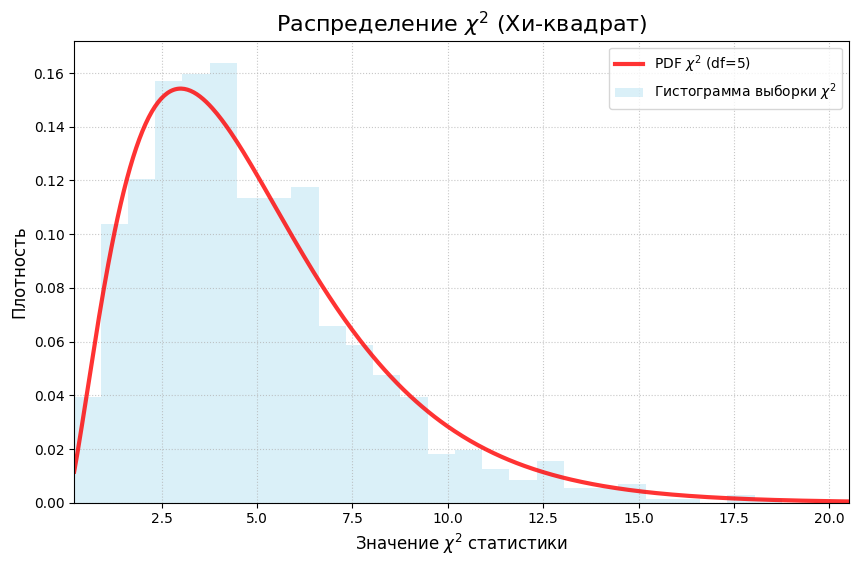

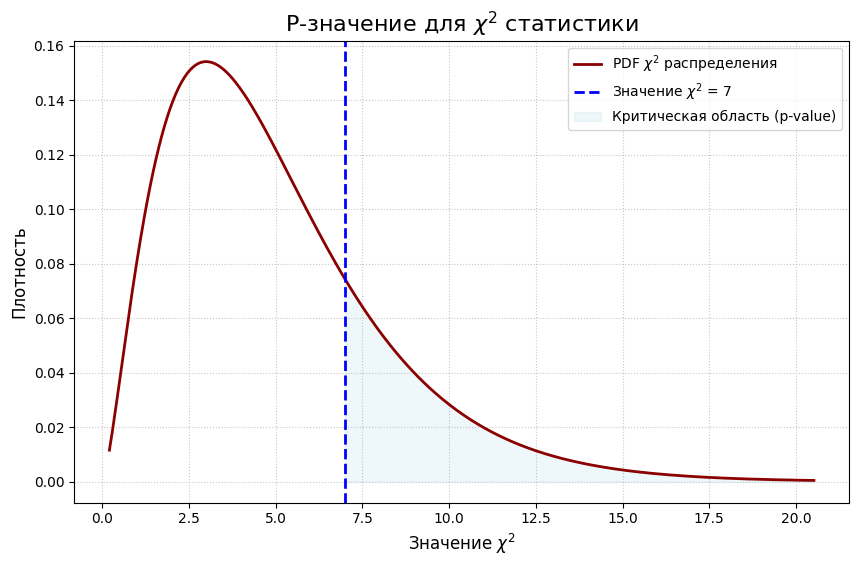

Значение p-value для $\chi^2$ = 7 с 5 степенями свободы = 0.221
  -> Не отвергаем H0: наблюдаемые частоты не отличаются статистически значимо от ожидаемых.

В этом примере используется одностороннее распределение (проверка 'слишком отличается').
Можно также использовать двустороннее распределение для проверки 'слишком похоже'.


In [28]:
alpha = 0.05
df_chi2 = 5  # Примем количество степеней свободы = 5

# Вычислим первые четыре момента (среднее, дисперсию, асимметрию, эксцесс) для распределения хи-квадрат
mean_chi2, var_chi2, skew_chi2, kurt_chi2 = sst.chi2.stats(df_chi2, moments='mvsk')

print(rf"Распределение $\chi^2$ со {df_chi2} степенями свободы:")
print(f"  Среднее: {mean_chi2:.3f}")
print(f"  Дисперсия: {var_chi2:.3f}")
print(f"  Асимметрия: {skew_chi2:.3f}")
print(f"  Эксцесс: {kurt_chi2:.3f}")

# Диапазон значений x для построения PDF
x_chi2 = np.linspace(sst.chi2.ppf(0.001, df_chi2),
                     sst.chi2.ppf(0.999, df_chi2),
                     500)

plt.figure(figsize=(10, 6))
# Отобразим функцию плотности вероятности (PDF) для хи-квадрат
plt.plot(x_chi2, sst.chi2.pdf(x_chi2, df_chi2), 'r-', lw=3, alpha=0.8, label=rf'PDF $\chi^2$ (df={df_chi2})')

# Генерация случайных чисел из распределения хи-квадрат для сравнения с гистограммой
r_chi2 = sst.chi2.rvs(df_chi2, size=1000)

# Сравним с гистограммой сгенерированных случайных чисел
plt.hist(r_chi2, bins='auto', density=True, histtype='stepfilled', alpha=0.3, color='skyblue', label=r'Гистограмма выборки $\chi^2$')

plt.xlim([x_chi2[0], x_chi2[-1]])
plt.title(r'Распределение $\chi^2$ (Хи-квадрат)', fontsize=16)
plt.xlabel(r'Значение $\chi^2$ статистики', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend(loc='best', frameon=True)
plt.grid(ls=':', alpha=0.7)
plt.show()

# Пример вычисления p-value для заданного значения статистики хи-квадрат
chi2_val = 7  # Произвольное значение статистики для примера
p_value_chi2 = sst.chi2.sf(chi2_val, df_chi2)  # sf (survival function) = 1 - cdf

plt.figure(figsize=(10, 6))
plt.plot(x_chi2, sst.chi2.pdf(x_chi2, df_chi2), color='darkred', linewidth=2, label=r"PDF $\chi^2$ распределения")
plt.axvline(chi2_val, color='blue', linestyle='--', linewidth=2, label=rf'Значение $\chi^2$ = {chi2_val}')

# Заштрихуем критическую область (хвост распределения, соответствующий p-value)
x_fill = np.linspace(chi2_val, x_chi2[-1], 100)
y_fill = sst.chi2.pdf(x_fill, df_chi2)
plt.fill_between(x_fill, y_fill, 0, where=(x_fill >= chi2_val), alpha=0.2, color='lightblue', label='Критическая область (p-value)')

plt.title(r'P-значение для $\chi^2$ статистики', fontsize=16)
plt.xlabel(r'Значение $\chi^2$', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend(loc='best')
plt.grid(ls=':', alpha=0.7)
plt.show()

print(rf"Значение p-value для $\chi^2$ = {chi2_val} с {df_chi2} степенями свободы = {p_value_chi2:.3f}")
if p_value_chi2 < alpha:
    print("  -> Отвергаем H0: статистически значимые отклонения от ожидаемых частот.")
else:
    print("  -> Не отвергаем H0: наблюдаемые частоты не отличаются статистически значимо от ожидаемых.")

print("\nВ этом примере используется одностороннее распределение (проверка 'слишком отличается').")
print("Можно также использовать двустороннее распределение для проверки 'слишком похоже'.")


### Применение теста $\chi^2$ к реальным данным

Для демонстрации теста $\chi^2$ с реальными данными мы попробуем загрузить данные из файла `123.prn`. Этот файл должен содержать числовые данные, возможно, с десятичной запятой вместо точки (что будет обработано).

Мы сравним наблюдаемое распределение наших данных с ожидаемым нормальным распределением, используя гистограммы для формирования частот по интервалам.

### Анализ данных из файла 123.prn ###
Прочитано 200 значений из файла 123.prn
Статистика загруженных данных:
  Минимум: 0.002130
  Максимум: 0.007866
  Среднее: 0.004924
  Медиана: 0.004966
  Стандартное отклонение: 0.001079
Описательная статистика (scipy.stats.describe):
DescribeResult(nobs=200, minmax=(np.float64(0.00213), np.float64(0.007866)), mean=np.float64(0.004923575), variance=np.float64(1.1691666677135675e-06), skewness=np.float64(-0.14666434119855143), kurtosis=np.float64(0.014337156431762477))

### Результаты теста χ² (наблюдаемые vs Нормальное распределение) ###
Значение статистики χ² = 3.754
p-значение = 0.440
  -> Гипотезу H0 не отклоняем (p >= 0.05). Данные соответствуют нормальному распределению.


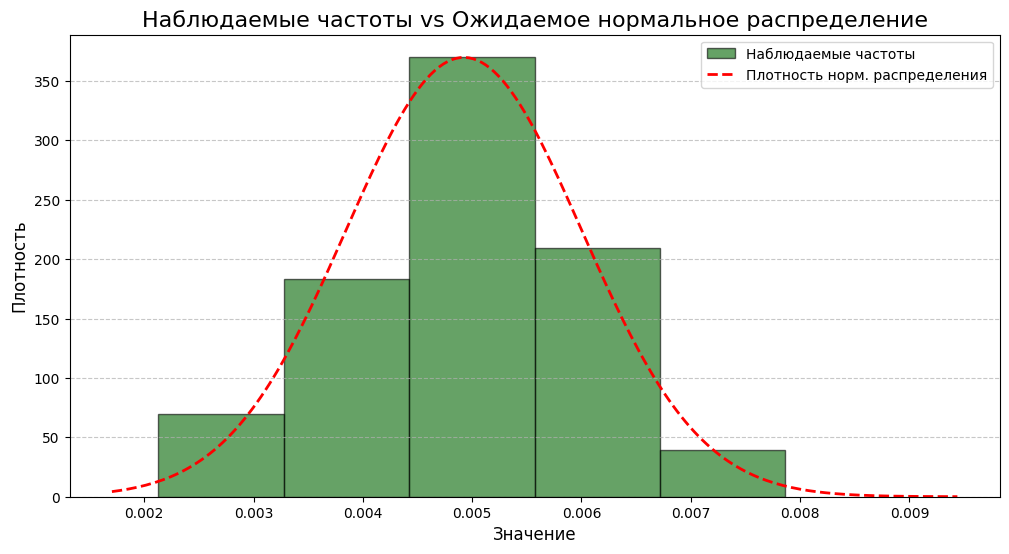

In [29]:
def analyze_prn_data():
    try:
        s_obs_str = np.loadtxt("123.prn", dtype="str")
        s_obs_numeric = np.array([float(so.replace(',', '.')) for so in s_obs_str])
        
        print(f"### Анализ данных из файла 123.prn ###")
        print(f"Прочитано {len(s_obs_numeric)} значений из файла 123.prn")
        print(f"Статистика загруженных данных:")
        print(f"  Минимум: {np.min(s_obs_numeric):.6f}")
        print(f"  Максимум: {np.max(s_obs_numeric):.6f}")
        print(f"  Среднее: {np.mean(s_obs_numeric):.6f}")
        print(f"  Медиана: {np.median(s_obs_numeric):.6f}")
        print(f"  Стандартное отклонение: {np.std(s_obs_numeric):.6f}")
        
        desc_ob = sst.describe(s_obs_numeric, axis=0, ddof=1, bias=True, nan_policy='propagate')
        print("Описательная статистика (scipy.stats.describe):")
        print(desc_ob)

        num_bins = 5  # уменьшил количество интервалов для увеличения ожидаемых частот
        
        counts_obs, bin_edges = np.histogram(s_obs_numeric, bins=num_bins)
        mu, sigma = np.mean(s_obs_numeric), np.std(s_obs_numeric)
        
        expected_probabilities = [
            sst.norm.cdf(bin_edges[i+1], loc=mu, scale=sigma) - sst.norm.cdf(bin_edges[i], loc=mu, scale=sigma)
            for i in range(num_bins)
        ]
        
        f_exp_counts = np.array(expected_probabilities) * len(s_obs_numeric)
        
        # Проверка на маленькие ожидаемые частоты
        if np.any(f_exp_counts < 5):
            print("\nПредупреждение: Некоторые ожидаемые частоты < 5. Рекомендуется объединить интервалы или использовать другой тест.")
        
        # Коррекция ожидаемых частот для точного совпадения суммы
        f_exp_counts = np.round(f_exp_counts)
        diff = np.sum(counts_obs) - np.sum(f_exp_counts)
        f_exp_counts[-1] += diff  # компенсируем разницу в последнем интервале

        # Степени свободы
        df = num_bins - 1 - 2  # 2 параметра оценки: среднее и std
        if df < 1:
            print("\nОшибка: Недостаточно степеней свободы для теста χ².")
            return

        chisq_stat, pvalue = sst.chisquare(counts_obs, f_exp=f_exp_counts)

        print(f"\n### Результаты теста χ² (наблюдаемые vs Нормальное распределение) ###")
        print(f"Значение статистики χ² = {chisq_stat:.3f}")
        print(f"p-значение = {pvalue:.3f}")

        alpha = 0.05
        if pvalue < alpha:
            print(f"  -> Гипотезу H0 можно отклонить (p < {alpha}). Данные не соответствуют нормальному распределению.")
        else:
            print(f"  -> Гипотезу H0 не отклоняем (p >= {alpha}). Данные соответствуют нормальному распределению.")

        plt.figure(figsize=(12, 6))
        plt.hist(s_obs_numeric, bins=bin_edges, density=True, alpha=0.6, color='darkgreen', edgecolor='black', label='Наблюдаемые частоты')
        x_plot_norm = np.linspace(np.min(s_obs_numeric)*0.8, np.max(s_obs_numeric)*1.2, 200)
        pdf_norm = sst.norm.pdf(x_plot_norm, loc=mu, scale=sigma)
        plt.plot(x_plot_norm, pdf_norm, 'r--', linewidth=2, label='Плотность норм. распределения')
        plt.title('Наблюдаемые частоты vs Ожидаемое нормальное распределение', fontsize=16)
        plt.xlabel('Значение', fontsize=12)
        plt.ylabel('Плотность', fontsize=12)
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

    except FileNotFoundError:
        print("Ошибка: Файл '123.prn' не найден.")
    except Exception as e:
        print(f"Произошла ошибка при обработке файла: {e}")

analyze_prn_data()


## 5. QQ-график (Quantile-Quantile Plot)

QQ-график — это графический метод сравнения двух распределений вероятностей путем отображения их квантилей друг против друга. Он используется для проверки того, следует ли набор данных определенному теоретическому распределению (например, нормальному).:

**Принцип работы:**
1.  Данные выборки сортируются по возрастанию.
2.  Для каждой точки данных вычисляется ее теоретический квантиль из заданного распределения (например, нормального распределения).
3.  На графике по оси X откладываются теоретические квантили, а по оси Y — наблюдаемые квантили выборки.

**Интерпретация:**
* Если два сравниваемых распределения схожи, точки на QQ-графике будут примерно лежать на прямой $y = x$.
* Отклонения от этой прямой указывают на различия в форме, центре или масштабе распределений (например, S-образная кривая может указывать на более тяжелые или легкие хвосты).

QQ-график — мощный инструмент для визуальной оценки нормальности или соответствия другим распределениям, который более информативен, чем простая гистограмма, но требует некоторого опыта для интерпретации.

Создадим функцию `QQ_plot` для построения такого графика.

<Figure size 800x800 with 0 Axes>

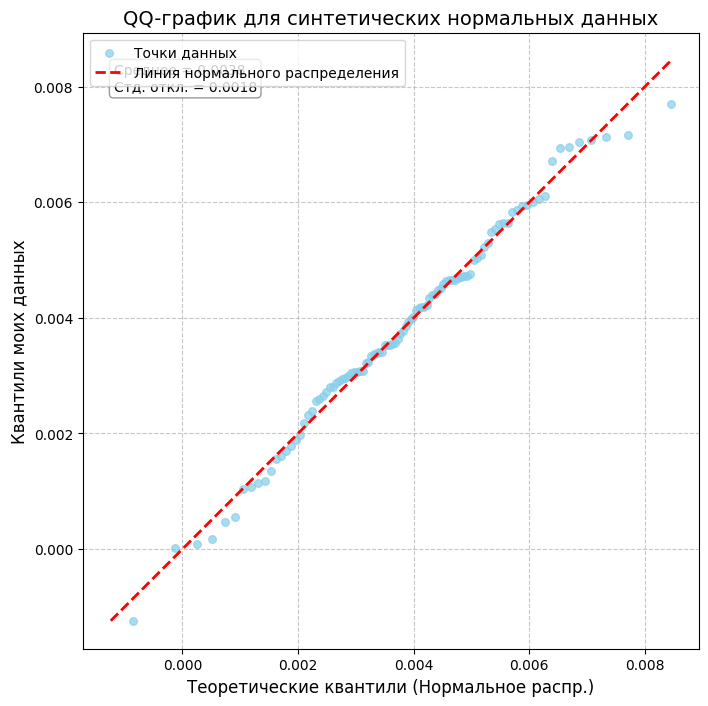

In [30]:
def QQ_plot(data, title="QQ-график", xlabel='Теоретические квантили (Нормальное распр.)',
            ylabel='Квантили моих данных', ax=None, color='skyblue'):
    """
    Строит QQ-график для сравнения данных с нормальным распределением.

    Parameters:
    - data (np.array): Входные данные для анализа.
    - title (str): Заголовок графика.
    - xlabel (str): Подпись оси X.
    - ylabel (str): Подпись оси Y.
    - ax (matplotlib.axes.Axes, optional): Объект осей Matplotlib для построения графика.
    - color (str): Цвет точек графика.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # 1. Сортировка данных по возрастанию (наблюдаемые квантили)
    observed_quantiles = np.sort(data)
    n_points = len(observed_quantiles)
    
    # 2. Оценка параметров нормального распределения из данных
    mean_data, std_data = np.mean(observed_quantiles), np.std(observed_quantiles)
    
    # 3. Вычисление теоретических квантилей нормального распределения
    # Используем формулу (i - 0.5) / N для позиций квантилей
    # sst.norm(loc, scale).ppf(q) - функция квантилей (Inverse CDF)
    percentile_positions = (np.arange(1, n_points + 1) - 0.5) / n_points
    theoretical_quantiles = sst.norm(loc=mean_data, scale=std_data).ppf(percentile_positions)

    # 4. Построение точечного графика Q-Q
    ax.scatter(theoretical_quantiles, observed_quantiles, color=color, alpha=0.7, 
               s=30, label='Точки данных')
    
    # 5. Построение диагональной линии (y = x)
    # Диагональ проходит через минимальное и максимальное значения обеих осей
    min_val = np.min([theoretical_quantiles, observed_quantiles])
    max_val = np.max([theoretical_quantiles, observed_quantiles])
    diag_line = np.linspace(min_val, max_val, 100)
    ax.plot(diag_line, diag_line, c='red', linestyle='--', linewidth=2, label='Линия нормального распределения')

    # Настройка графика
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_aspect('equal', adjustable='box') # График квадратной формы для лучшей визуализации
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper left', fontsize=10)
    
    # Добавление информации о статистических параметрах
    stats_text = f'Среднее = {mean_data:.4f}\nСтд. откл. = {std_data:.4f}'
    ax.annotate(stats_text, xy=(0.05, 0.95), xycoords='axes fraction',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                 fontsize=10, verticalalignment='top')

# Сделаем для теста произвольные нормальные данные
np.random.seed(42) # Для воспроизводимости
test_normal_data = sst.norm.rvs(loc=0.004, scale=0.002, size=100)

plt.figure(figsize=(8, 8))
QQ_plot(test_normal_data, title='QQ-график для синтетических нормальных данных')
plt.show()


### Построение QQ-графика для данных из файла `123.prn`

Теперь применим функцию `QQ_plot` к данным, загруженным из файла `123.prn`. Мы построим два графика: для исходных данных и для масштабированных данных, чтобы посмотреть, как масштабирование влияет на визуализацию (хотя оно не меняет форму распределения).

Загружено 200 значений из файла 123.prn
Статистика загруженных данных:
  Минимум: 0.002130
  Максимум: 0.007866
  Среднее: 0.004924
  Медиана: 0.004966
  Стандартное отклонение: 0.001079


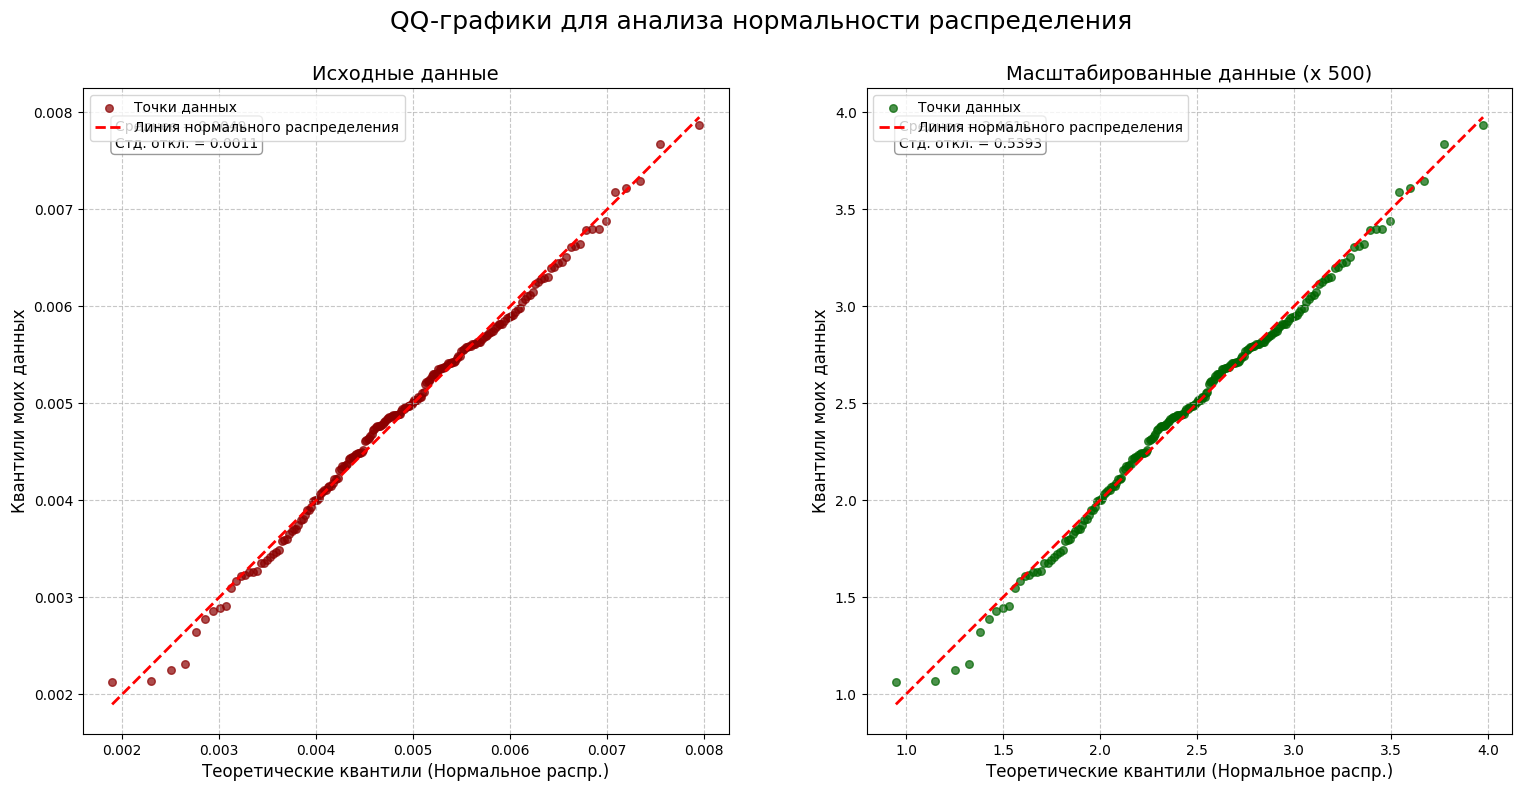


### Результаты теста Шапиро-Уилка на нормальность: ###
  Статистика W: 0.993874
  p-значение: 0.581972
  Вывод: Данные соответствуют нормальному распределению (p >= 0.05).


In [31]:
# Основная функция для загрузки данных и построения QQ-графиков
def main_qq_plot_analysis():
    try:
        # Загрузка данных из файла 123.prn
        s_obs_str = np.loadtxt("123.prn", dtype="str")
        # Преобразование строк в числа, заменяя запятые на точки
        s_obs_numeric = np.array([float(so.replace(',', '.')) for so in s_obs_str])
        
        print(f"Загружено {len(s_obs_numeric)} значений из файла 123.prn")
        print(f"Статистика загруженных данных:")
        print(f"  Минимум: {np.min(s_obs_numeric):.6f}")
        print(f"  Максимум: {np.max(s_obs_numeric):.6f}")
        print(f"  Среднее: {np.mean(s_obs_numeric):.6f}")
        print(f"  Медиана: {np.median(s_obs_numeric):.6f}")
        print(f"  Стандартное отклонение: {np.std(s_obs_numeric):.6f}")
        
        # Создадим фигуру с двумя графиками: для исходных и масштабированных данных
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        fig.suptitle('QQ-графики для анализа нормальности распределения', fontsize=18)
        
        # QQ-график для исходных данных
        QQ_plot(s_obs_numeric, title='Исходные данные', ax=axes[0], color='darkred')
        
        # Масштабируем данные (умножаем на 500) для второго графика
        s_obs_scaled = s_obs_numeric * 500
        QQ_plot(s_obs_scaled, title='Масштабированные данные (x 500)', ax=axes[1], color='darkgreen')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Регулировка layout для заголовка
        plt.show()
        
        # Дополнительно: проверка на нормальность с помощью теста Шапиро-Уилка
        # Тест Шапиро-Уилка считается одним из наиболее мощных тестов на нормальность.
        shapiro_stat, shapiro_p = sst.shapiro(s_obs_numeric)
        print("\n### Результаты теста Шапиро-Уилка на нормальность: ###")
        print(f"  Статистика W: {shapiro_stat:.6f}")
        print(f"  p-значение: {shapiro_p:.6f}")
        
        alpha_shapiro = 0.05
        if shapiro_p < alpha_shapiro:
            print(f"  Вывод: Данные не соответствуют нормальному распределению (p < {alpha_shapiro}).")
        else:
            print(f"  Вывод: Данные соответствуют нормальному распределению (p >= {alpha_shapiro}).")
        
    except FileNotFoundError:
        print("Файл 123.prn не найден. Создаю демонстрационный пример и перезапускаю...\n")
        # Создаем демонстрационные данные для файла 123.prn, если его нет
        np.random.seed(42)  # для воспроизводимости
        demo_data = np.random.normal(loc=0.004, scale=0.002, size=100)
        np.savetxt("123.prn", demo_data, fmt='%.6f', delimiter=',', newline='\n')
        
        print("Демонстрационный файл 123.prn создан. Пожалуйста, перезапустите этот блок кода.")
    
    except Exception as e:
        print(f"Произошла ошибка: {e}")

main_qq_plot_analysis()
